# ML CLASSIFICATION + REGRESSION ON PIMA INDIAN DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import warnings

warnings.filterwarnings("ignore")


In [ ]:
!pip install kagglehub
import kagglehub

In [ ]:
import pandas as pd
import os
diabetes_data=  "/content/diabetes (1).csv"
diabetes_data = pd.read_csv(diabetes_data)
display(diabetes_data.shape)

(768, 9)

In [ ]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


True
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']


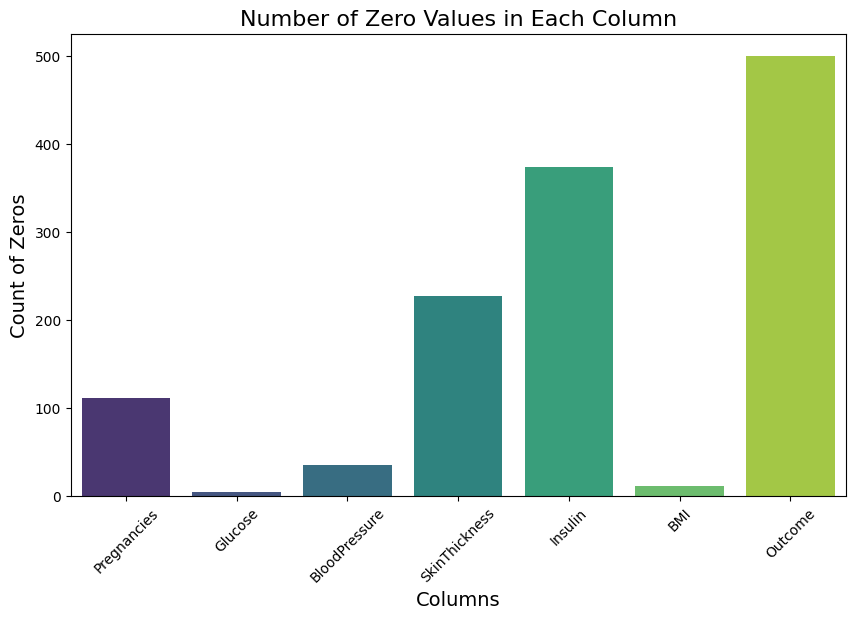

In [ ]:
#check zeros in columns
zero_data= (diabetes_data == 0).any().any()
print(zero_data)

cols_zeros= diabetes_data.columns[(diabetes_data==0).any()].tolist()
print(cols_zeros)

# Calculate zero counts for relevant columns
zero_counts = (diabetes_data[cols_zeros] == 0).sum()

plt.figure(figsize=(10,6))
sns.barplot(x=zero_counts.index, y=zero_counts.values, palette="viridis")

plt.title("Number of Zero Values in Each Column", fontsize=16)
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Count of Zeros", fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#The distribution of the Outcome variable
outcome=diabetes_data["Outcome"].value_counts()
result=outcome*100/len(diabetes_data)
result

,count
Outcome,
0,65.104167
1,34.895833


<Axes: xlabel='Outcome', ylabel='Density'>

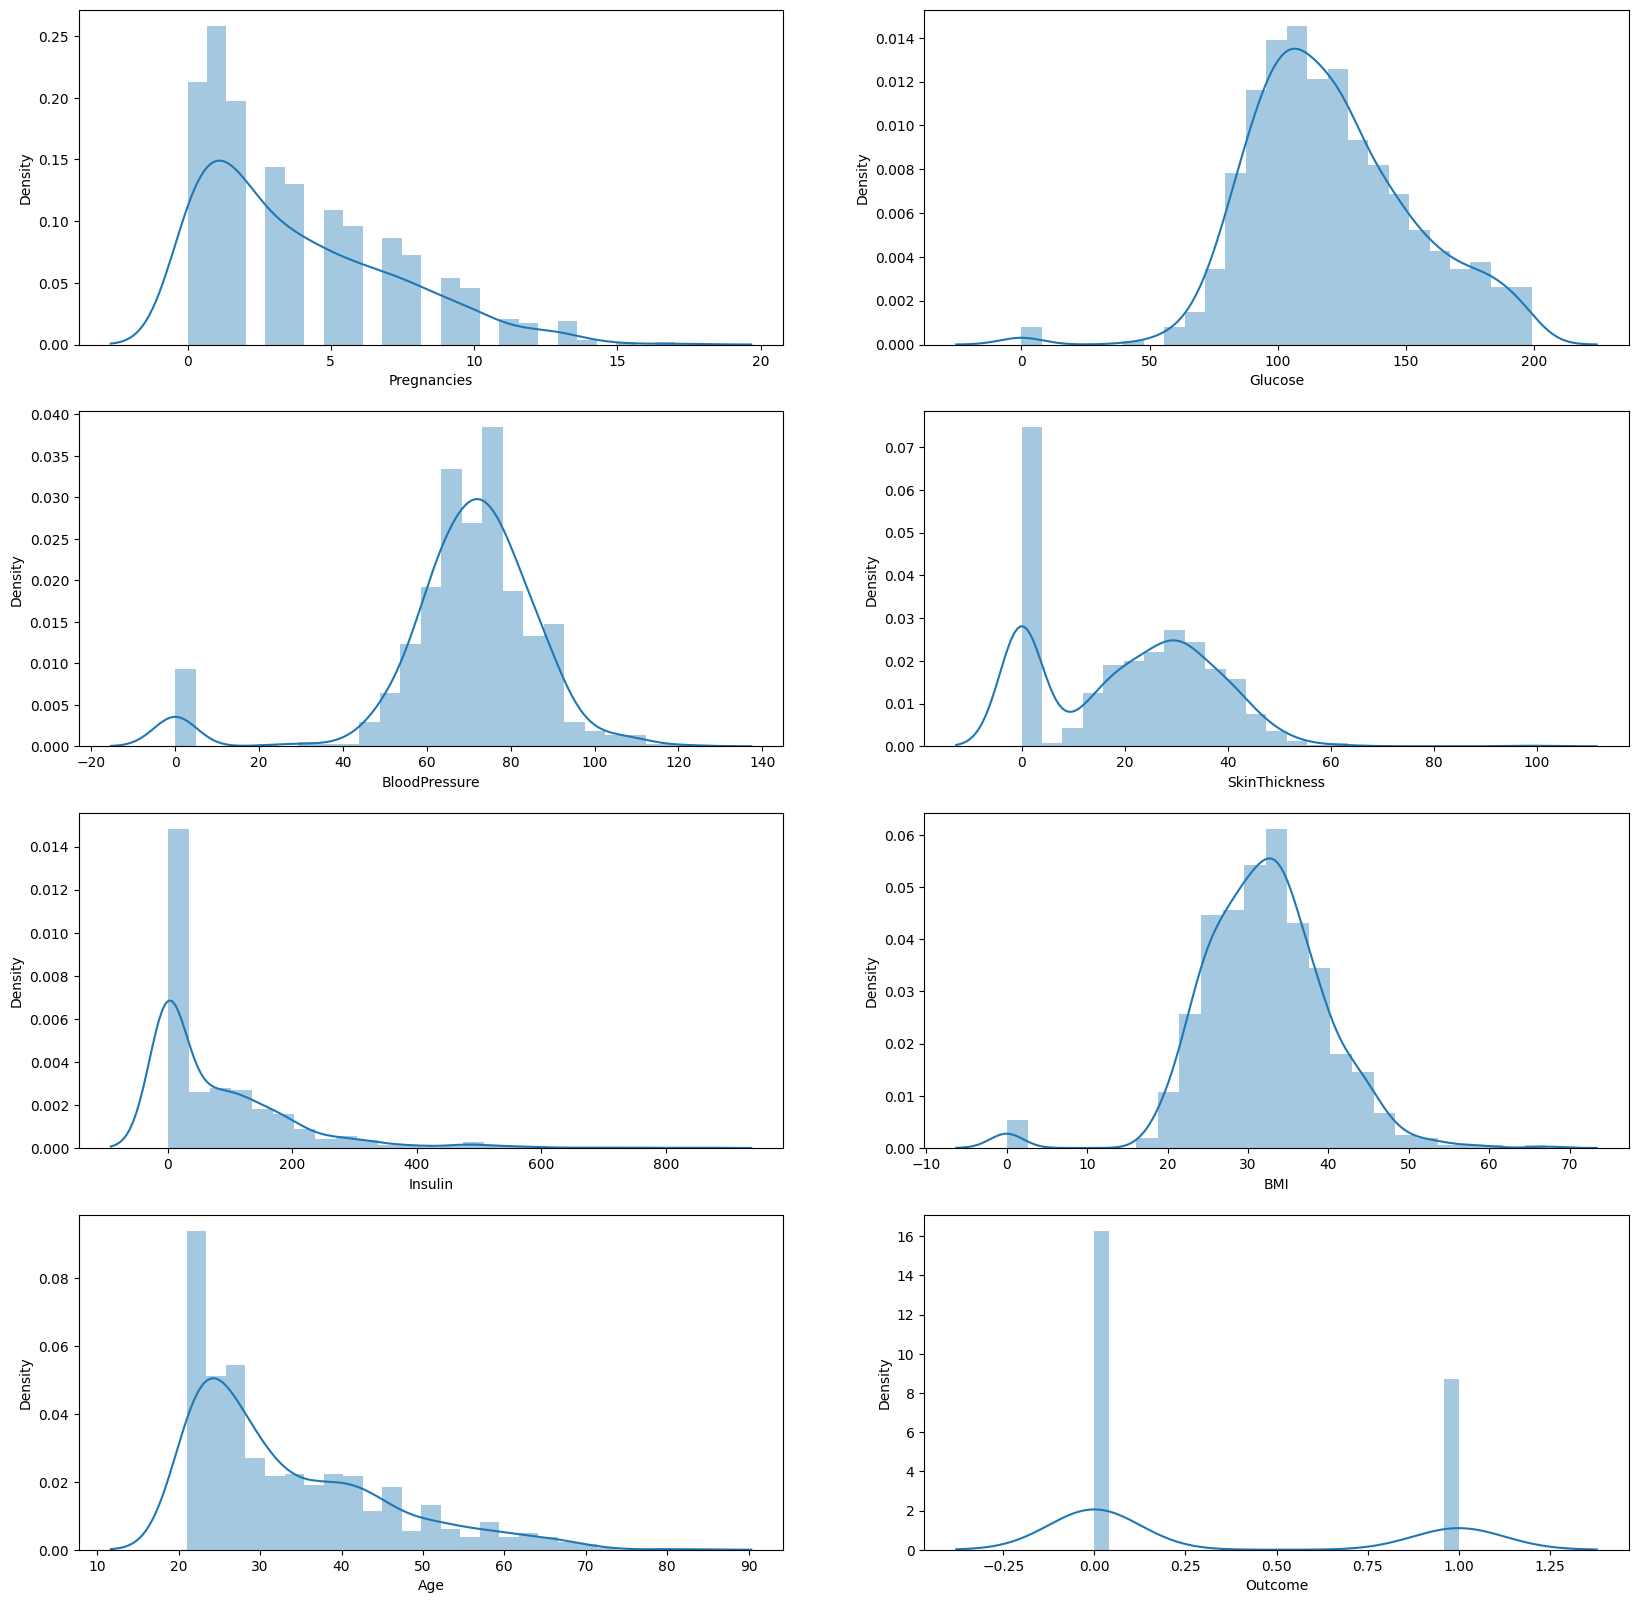

In [ ]:
fig,ax= plt.subplots(4,2,figsize=(20,20))
sns.distplot(diabetes_data.Pregnancies,bins=25,ax=ax[0,0])
sns.distplot(diabetes_data.Glucose, bins = 25, ax=ax[0,1])
sns.distplot(diabetes_data.BloodPressure, bins = 25, ax=ax[1,0])
sns.distplot(diabetes_data.SkinThickness, bins = 25, ax=ax[1,1])
sns.distplot(diabetes_data.Insulin, bins = 25, ax=ax[2,0])
sns.distplot(diabetes_data.BMI, bins = 25, ax=ax[2,1])
sns.distplot(diabetes_data.Age, bins = 25, ax=ax[3,0])
sns.distplot(diabetes_data.Outcome, bins = 25, ax=ax[3,1])


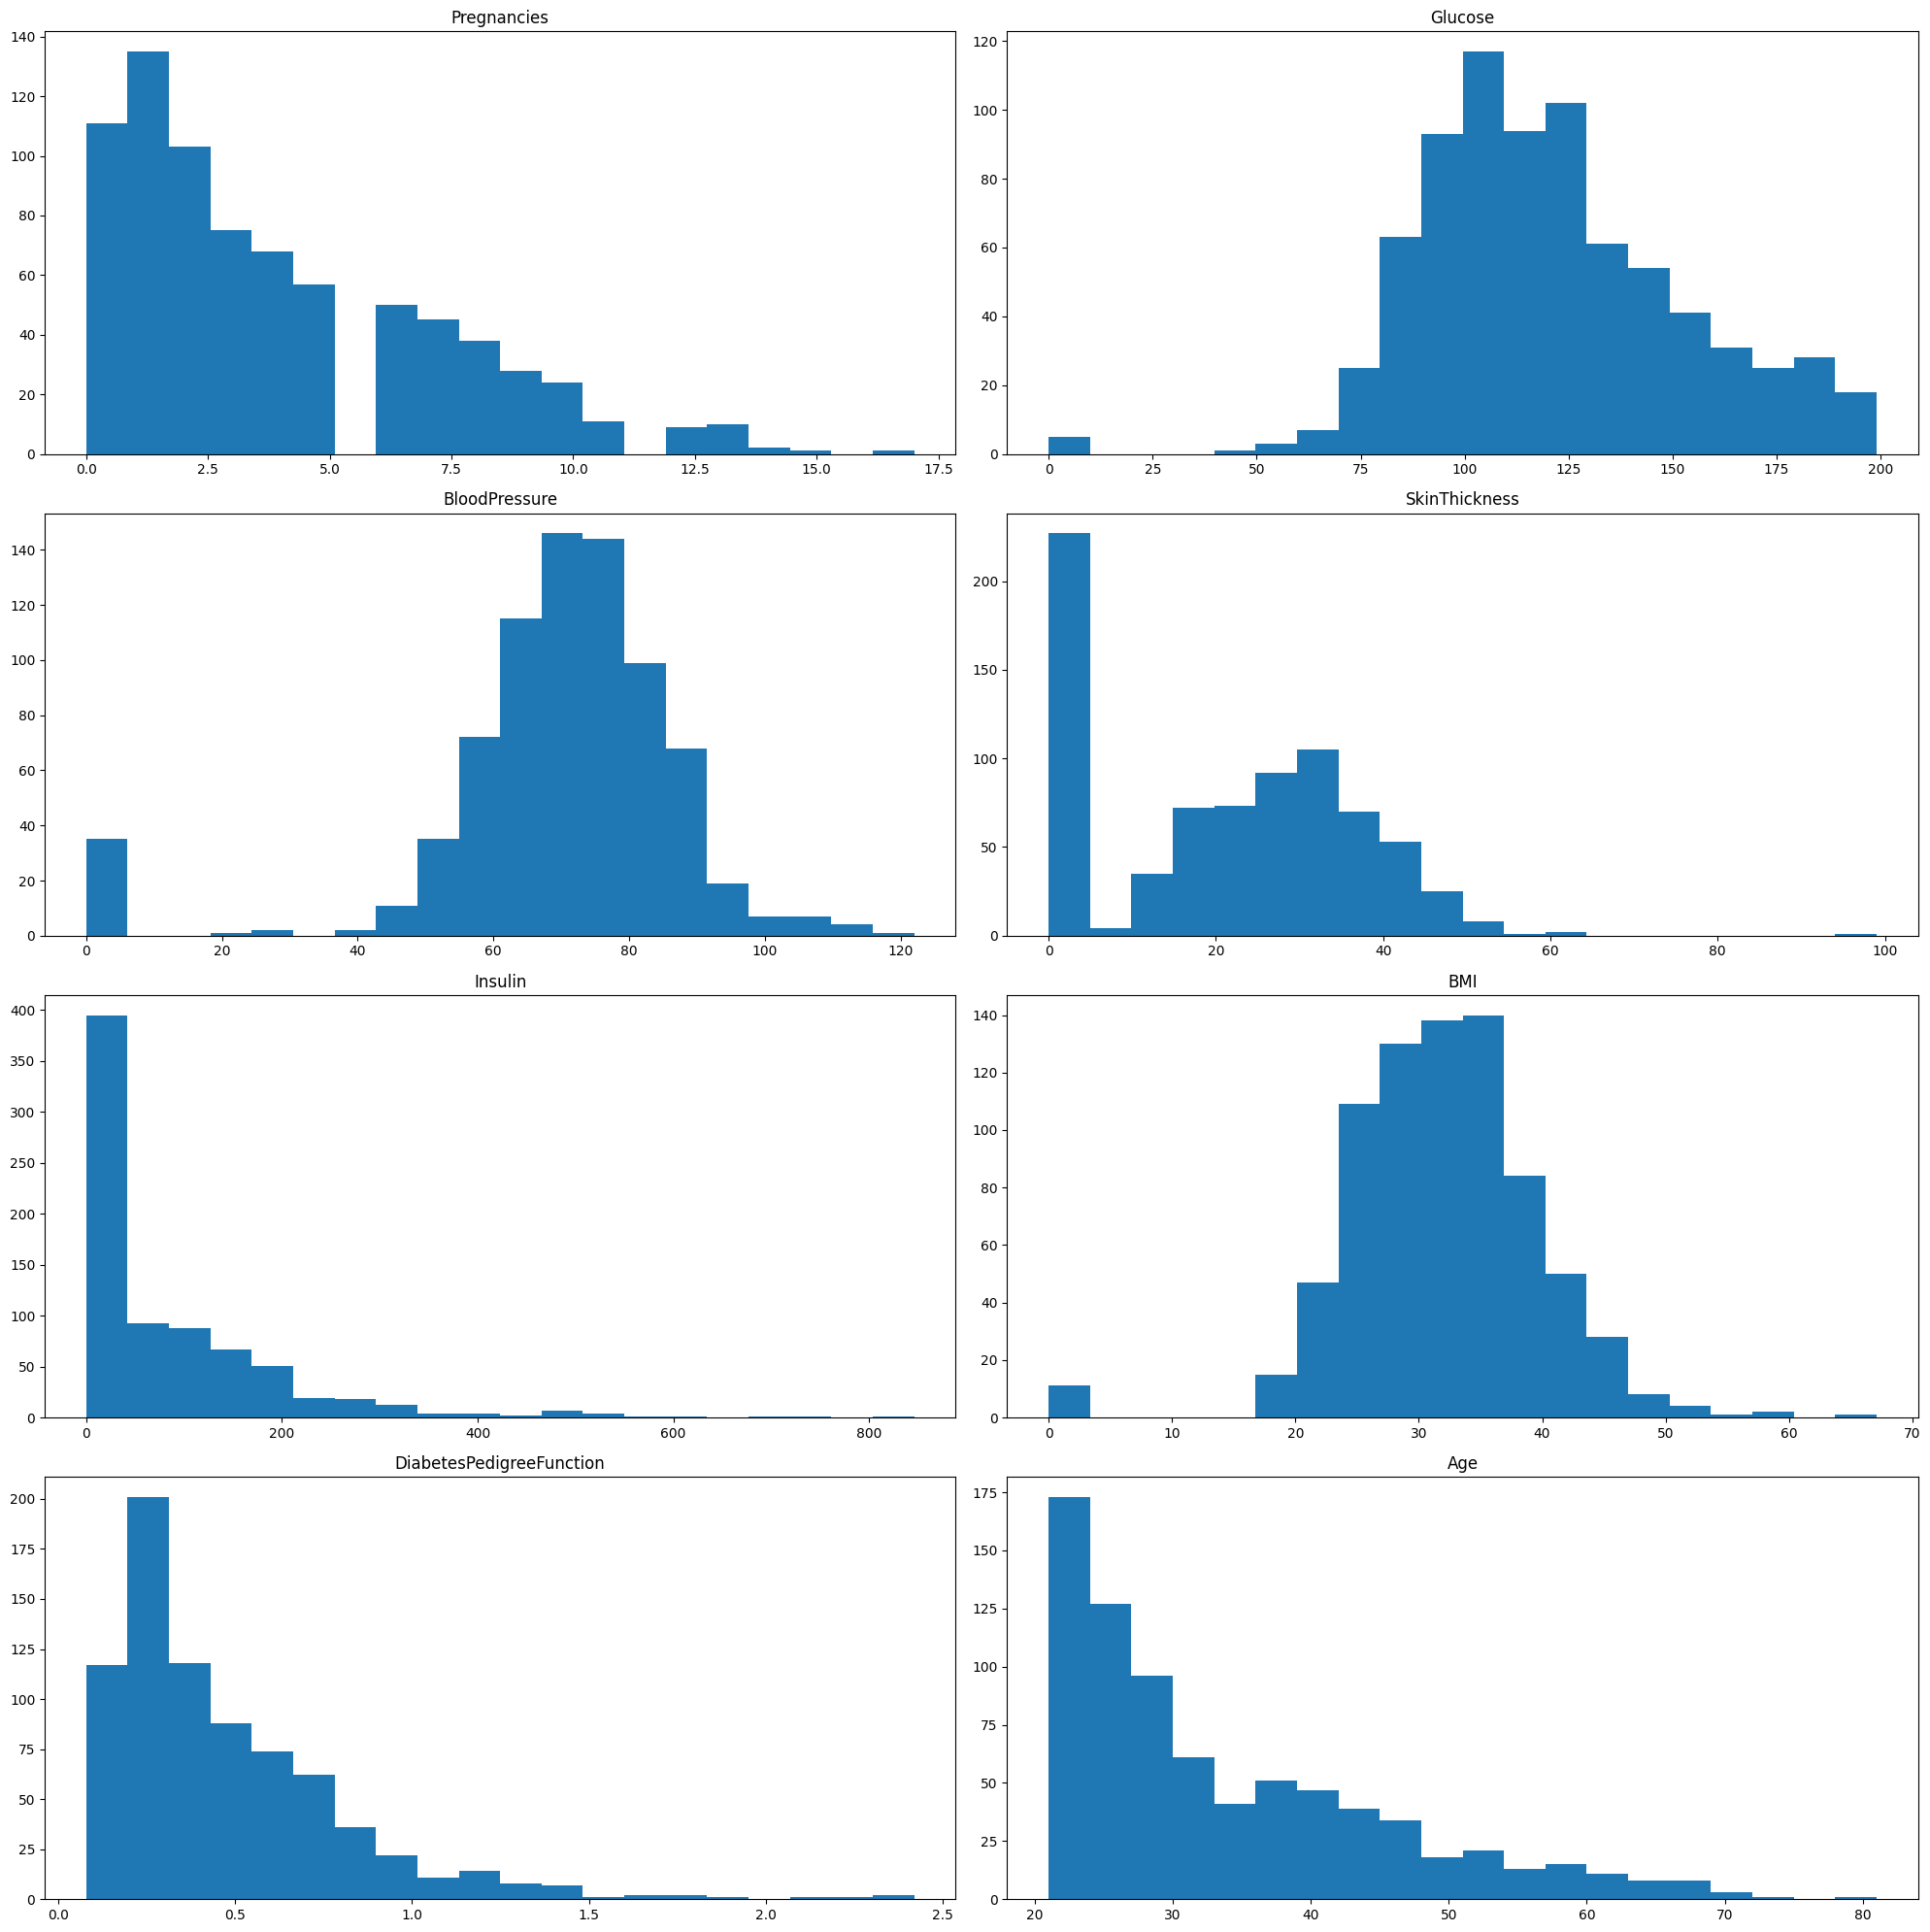

In [ ]:
#histogram for differnt features
cols= diabetes_data.columns[:8]
plt.figure(figsize=(20,20))

for i in range(len(cols)):
    plt.subplot(4,2,i+1)
    plt.hist(diabetes_data[cols[i]],bins=20)
    plt.title(cols[i])
plt.tight_layout()
plt.show()

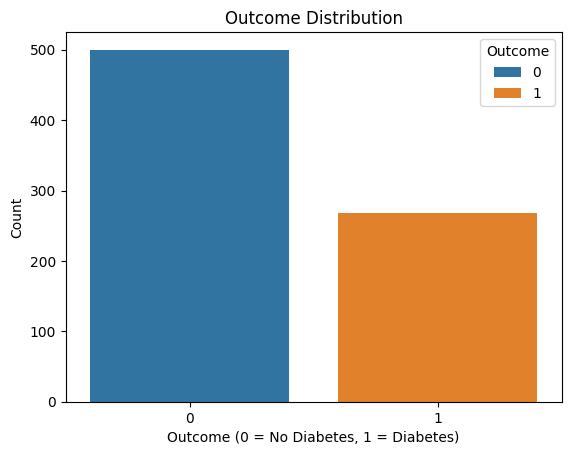

In [ ]:
sns.countplot(data=diabetes_data, x='Outcome', hue='Outcome')
plt.title("Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

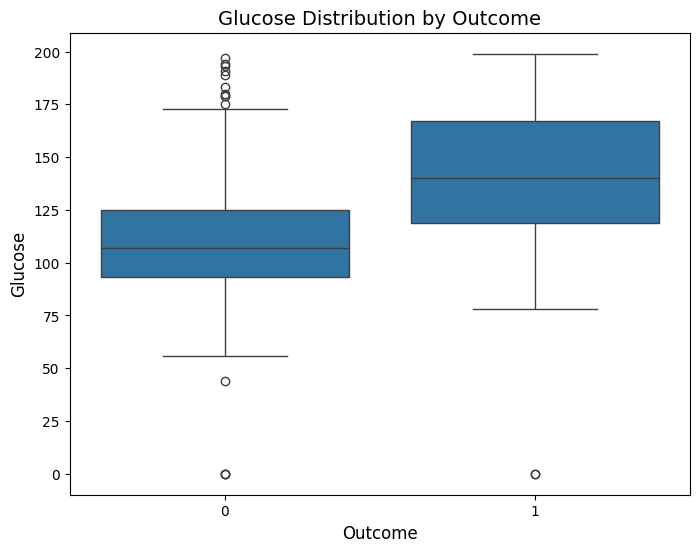

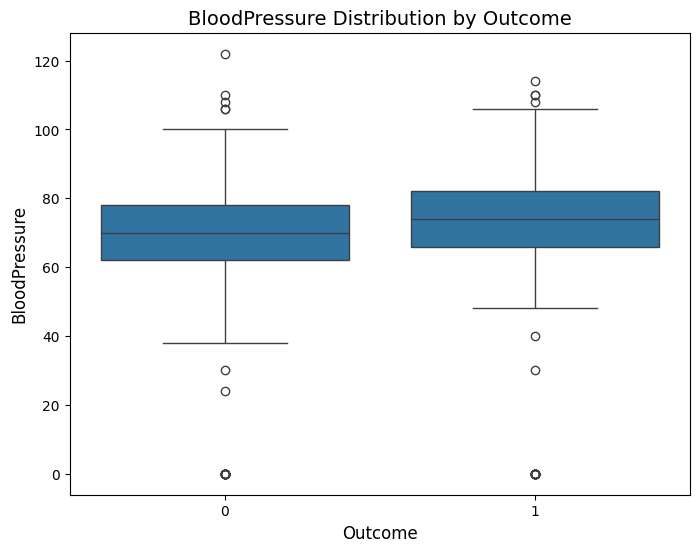

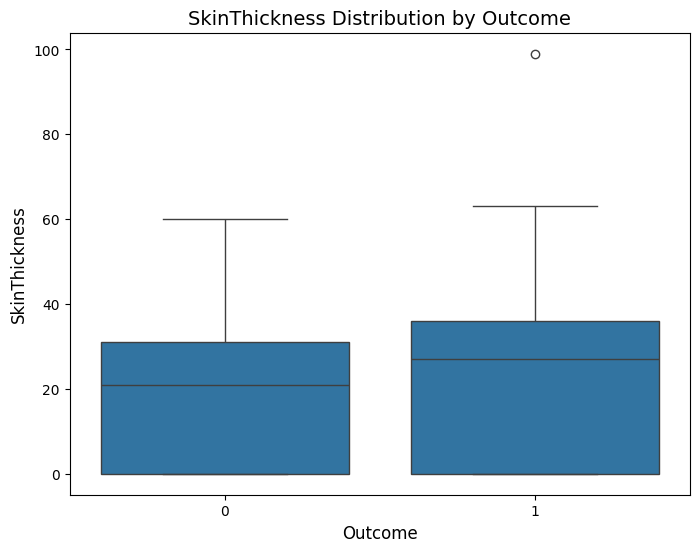

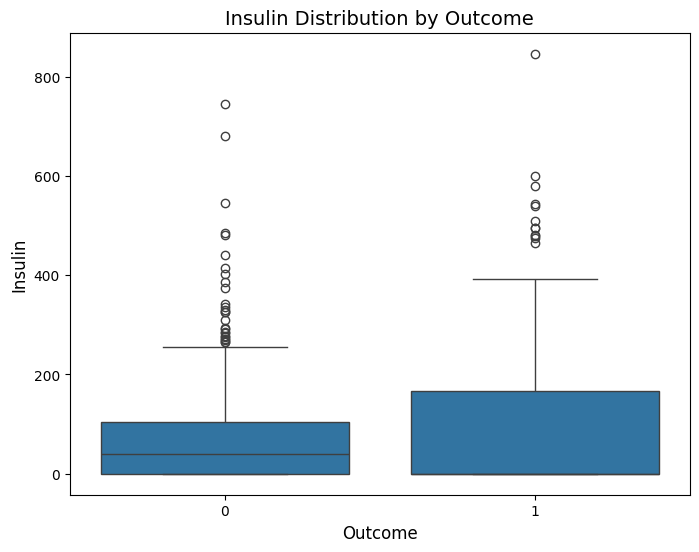

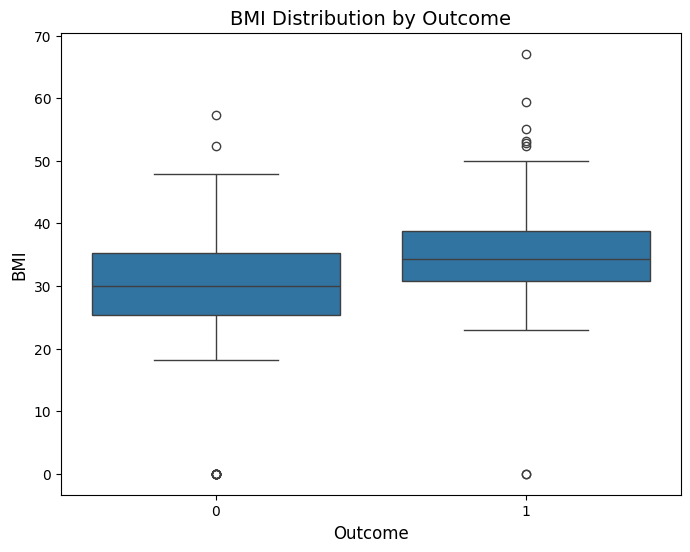

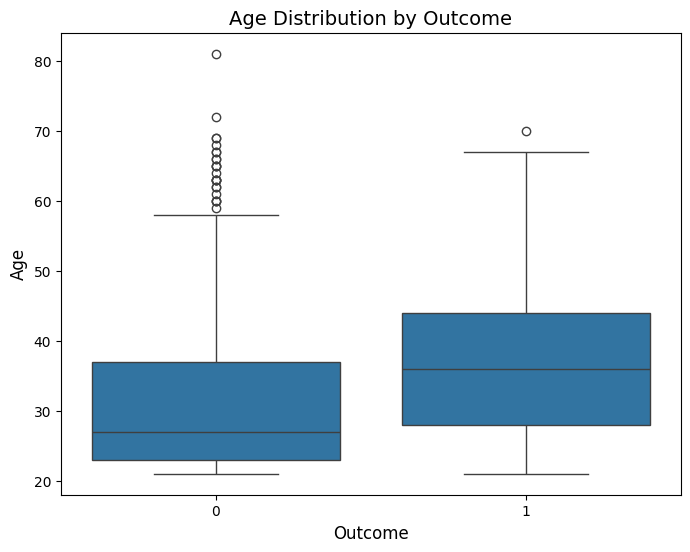

In [ ]:
features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=diabetes_data, x="Outcome", y=feature)
    plt.title(f"{feature} Distribution by Outcome", fontsize=14)
    plt.xlabel("Outcome", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.show()

In [ ]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#some cols has min value  0,
col_with_zero= ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in col_with_zero:
  zeros_count=(diabetes_data[col]== 0).sum()
  zeros_per= 100* ( zeros_count/ len(diabetes_data))
  print(f"{col}: {zeros_count} {zeros_per}%")

  # glucose, bp, bmi has less 0 value, so we can drop
  # skinthickness,insulin has more 0 value, so use filling

Glucose: 5 0.6510416666666667%
BloodPressure: 35 4.557291666666666%
SkinThickness: 227 29.557291666666668%
Insulin: 374 48.69791666666667%
BMI: 11 1.4322916666666665%


In [ ]:
#rows which have replace 0 with NaN
for col in col_with_zero:
  diabetes_data[col]= diabetes_data[col].replace(0, np.nan)

In [ ]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
dia= diabetes_data.dropna(subset=['Glucose', 'BloodPressure', 'BMI'])

In [ ]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
# Replaces NaN in SkinThickness & Insulin with the median of that column.
col_fill=["SkinThickness","Insulin"]
median_col={}
for col in col_fill:
  median_val= dia[dia[col] != "NaN"][col].median()
  median_col[col]= median_val
  median_val= dia[col].median()
  dia[col]= dia[col].fillna(median_val)

In [ ]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 724 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    int64  
 1   Glucose                   724 non-null    float64
 2   BloodPressure             724 non-null    float64
 3   SkinThickness             724 non-null    float64
 4   Insulin                   724 non-null    float64
 5   BMI                       724 non-null    float64
 6   DiabetesPedigreeFunction  724 non-null    float64
 7   Age                       724 non-null    int64  
 8   Outcome                   724 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 56.6 KB


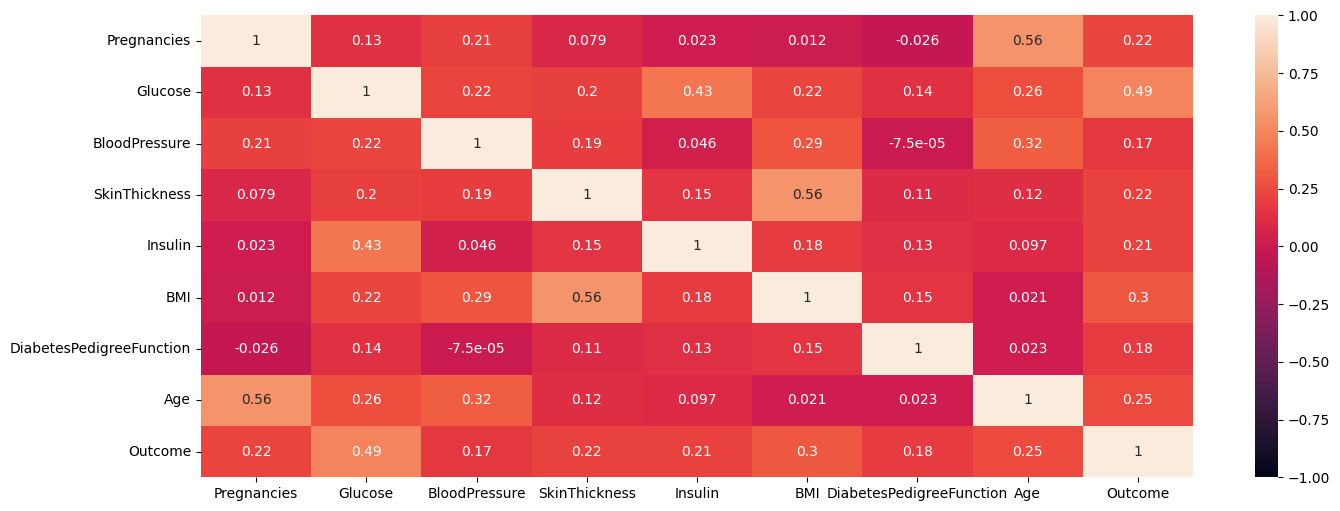

In [ ]:
plt.figure(figsize=(16,6))
heatmap1=sns.heatmap(dia.corr(),vmin=-1,vmax=1,annot=True,annot_kws={"size":10})

In [ ]:
#train-test-split
x= dia.drop("Outcome", axis=1)
y= dia["Outcome"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.3)
# 30% of the data goes into the test set, 70% into the train set.

In [ ]:
# standardizes features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [ ]:
#Dictionary of ML classifiers
models_cal={
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
}

In [ ]:
#Function to calculate accuracy, confusion matrix, and classification report.
def cal_model_metrics(y_true,y_predict):
  metrics={
      "accuracy": accuracy_score(y_true, y_predict),
      "confusion matrix": confusion_matrix(y_true, y_predict),
      " classification report": classification_report(y_true, y_predict)
  }
  return metrics



In [ ]:
for name,model1 in models_cal.items():
  model1.fit(x_train, y_train) # Train the model using training data.
  y_train_predict= model1.predict(x_train) #Predict outcomes for train and test data.
  y_test_predict= model1.predict(x_test) #Predict outcomes for train and test data.
  print(f"model: {name}")
  result=cal_model_metrics(y_test, y_test_predict)
  print(f"accuracy: {result['accuracy']}")
  print("confusion matrix:")
  print(f"{result['confusion matrix']}")
  print("classification report:")
  print(f" {result[' classification report']}")
  print("-"*35)

model: Logistic Regression
accuracy: 0.7752293577981652
confusion matrix:
[[130  16]
 [ 33  39]]
classification report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       146
           1       0.71      0.54      0.61        72

    accuracy                           0.78       218
   macro avg       0.75      0.72      0.73       218
weighted avg       0.77      0.78      0.77       218

-----------------------------------
model: K-Nearest Neighbors
accuracy: 0.7477064220183486
confusion matrix:
[[120  26]
 [ 29  43]]
classification report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81       146
           1       0.62      0.60      0.61        72

    accuracy                           0.75       218
   macro avg       0.71      0.71      0.71       218
weighted avg       0.75      0.75      0.75       218

-----------------------------------
model: Naive Bayes
accuracy: 0.7

In [ ]:
#logistric regression-- highest accuracy -- strong recall for class 0 but weaker recall for class 1 meaning detects negatives very well,misses some +ve-- balance precidion-- 77%



In [ ]:
#random forest  77.5% sccuracy-- better balance between precision/recall
#svm -- 76.6% accuracy, strng recall for class 0 weaker for class 1
# naive bayes -- adaBoost - around 76% acuuracy

# k-nearest neighbors, decision tree-- weaker performance--

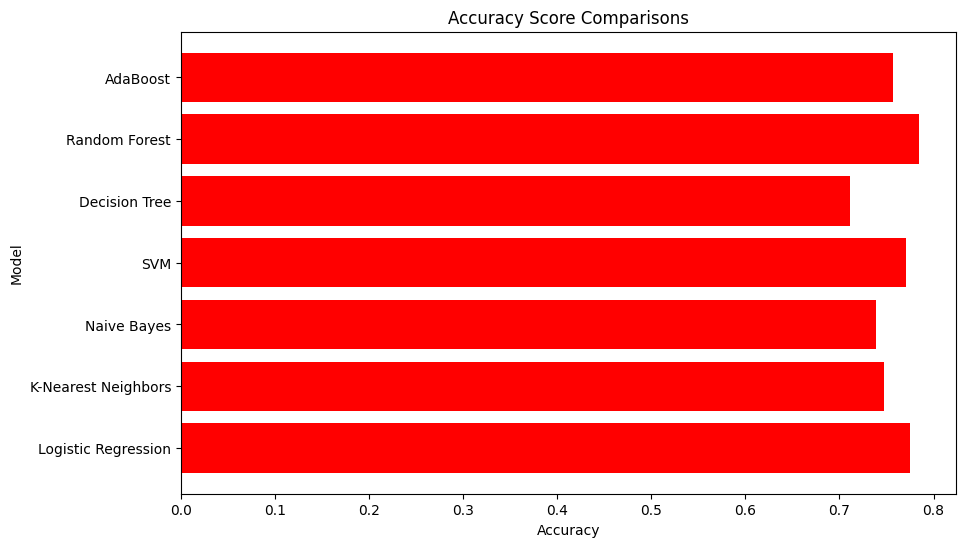

In [ ]:
model_names = list(models_cal.keys())
results = []

for model_name, model in models_cal.items():
    y_test_pred = model.predict(x_test)
    results.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.barh(model_names, results, color='red')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Accuracy Score Comparisons')
plt.show()

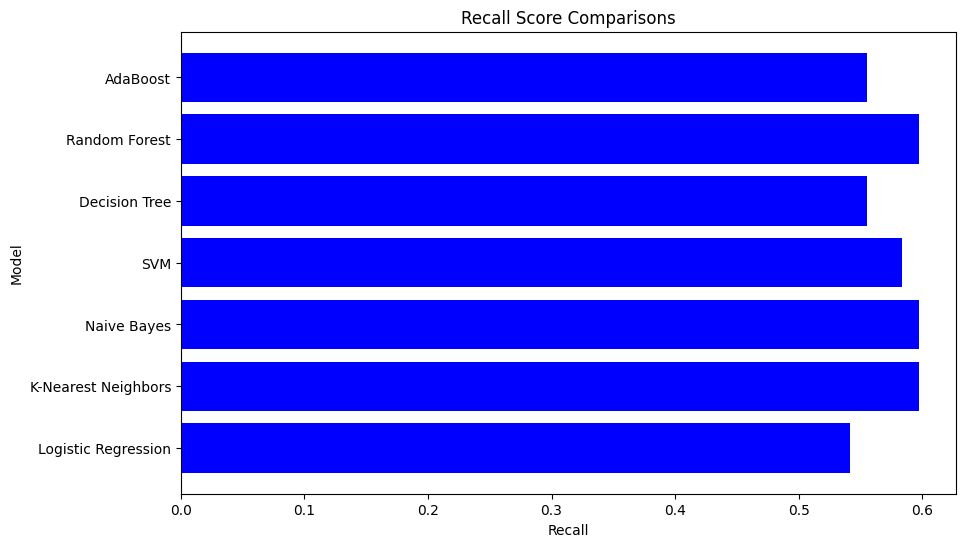

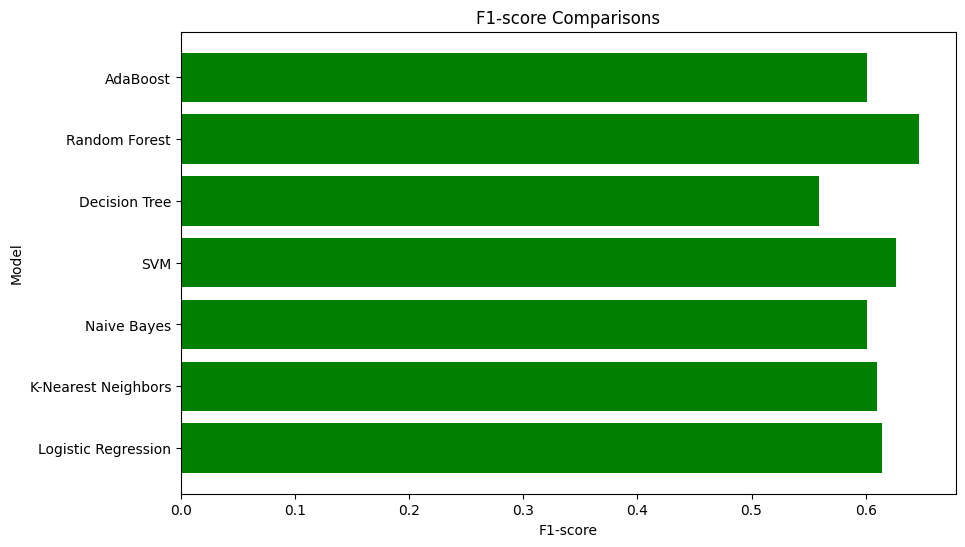

In [ ]:
from sklearn.metrics import recall_score, f1_score

model_names = list(models_cal.keys())
recall_results = []
f1_results = []

for model_name, model in models_cal.items():
    y_test_pred = model.predict(x_test)

    recall_results.append(recall_score(y_test, y_test_pred))
    f1_results.append(f1_score(y_test, y_test_pred))

# Recall Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(model_names, recall_results, color='blue')
plt.xlabel('Recall')
plt.ylabel('Model')
plt.title('Recall Score Comparisons')
plt.show()

# F1-score Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(model_names, f1_results, color='green')
plt.xlabel('F1-score')
plt.ylabel('Model')
plt.title('F1-score Comparisons')
plt.show()


In [ ]:
#regression

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
#Fits the model on training data.
def cal_model(true,predict):
  mae= mean_absolute_error(true, predict)
  mse= mean_squared_error(true, predict)
  rmse= np.sqrt(mse)
  r2= r2_score(true, predict)
  return mae, rmse, r2

In [ ]:
models = {
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "K-Neighbors": KNeighborsRegressor(),
    "SVR": SVR()
}

In [ ]:
for name,model1 in models.items():
  model1.fit(x_train, y_train)
  y_train_predict= model1.predict(x_train) #Train each model using training data
  y_test_predict= model1.predict(x_test) # predict on test data
  #Predict outputs for both training and test data to evaluate performance
  train_mae,train_rmse,train_r2= cal_model(y_train, y_train_predict)
  test_mae,test_rmse,test_r2= cal_model(y_test, y_test_predict)

  print(f"Model: {name}")
  print("Train Evaluation:")
  print(f"  MAE: {train_mae:.4f}")
  print(f"  RMSE: {train_rmse:.4f}")
  print(f"  R2: {train_r2:.4f}")
  print("Test Evaluation:")
  print(f"  MAE: {test_mae:.4f}")
  print(f"  RMSE: {test_rmse:.4f}")
  print(f"  R2: {test_r2:.4f}")
  print("-" * 35)


Model: Lasso
Train Evaluation:
  MAE: 0.4549
  RMSE: 0.4769
  R2: 0.0000
Test Evaluation:
  MAE: 0.4490
  RMSE: 0.4707
  R2: -0.0017
-----------------------------------
Model: Ridge
Train Evaluation:
  MAE: 0.3256
  RMSE: 0.3938
  R2: 0.3182
Test Evaluation:
  MAE: 0.3218
  RMSE: 0.3939
  R2: 0.2985
-----------------------------------
Model: Decision Tree
Train Evaluation:
  MAE: 0.0000
  RMSE: 0.0000
  R2: 1.0000
Test Evaluation:
  MAE: 0.2798
  RMSE: 0.5290
  R2: -0.2650
-----------------------------------
Model: Random Forest
Train Evaluation:
  MAE: 0.1114
  RMSE: 0.1498
  R2: 0.9014
Test Evaluation:
  MAE: 0.2945
  RMSE: 0.3959
  R2: 0.2915
-----------------------------------
Model: Gradient Boosting
Train Evaluation:
  MAE: 0.1859
  RMSE: 0.2494
  R2: 0.7266
Test Evaluation:
  MAE: 0.3036
  RMSE: 0.3932
  R2: 0.3012
-----------------------------------
Model: AdaBoost
Train Evaluation:
  MAE: 0.3183
  RMSE: 0.3773
  R2: 0.3741
Test Evaluation:
  MAE: 0.3568
  RMSE: 0.4210
  R2: 0.

In [ ]:
!pip install tensorflow

# **XAI Section using SHAP on MLP**

Classification (Logistic Regression) → outputs 0 or 1 directly, optimized for classification accuracy.

Regression (Linear Regression) → outputs continuous values like [0.23, 1.07, -0.12, 0.65, …].




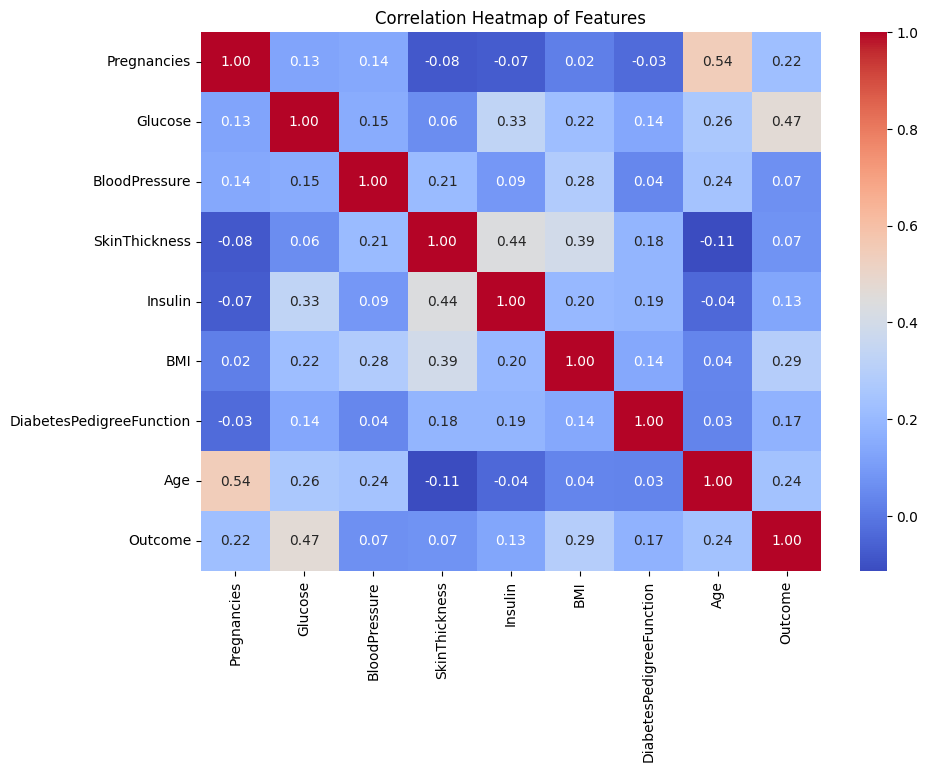

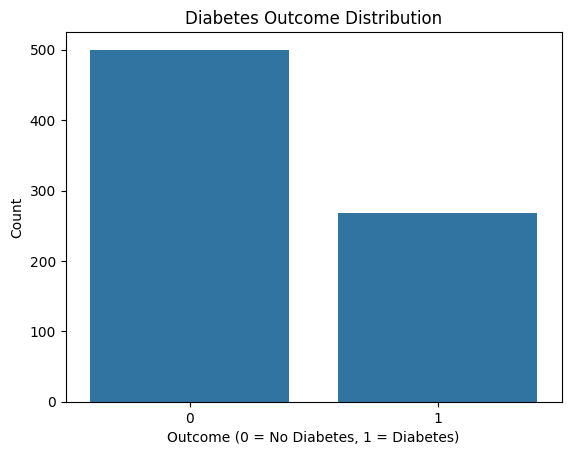

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6456 - loss: 0.7600 - val_accuracy: 0.6911 - val_loss: 0.6117
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6621 - loss: 0.7067 - val_accuracy: 0.7724 - val_loss: 0.5682
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6782 - loss: 0.6419 - val_accuracy: 0.7967 - val_loss: 0.5408
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7274 - loss: 0.5733 - val_accuracy: 0.8049 - val_loss: 0.5220
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7023 - loss: 0.6419 - val_accuracy: 0.7886 - val_loss: 0.5119
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7436 - loss: 0.5696 - val_accuracy: 0.7886 - val_loss: 0.5028
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7240 - loss: 0.5996 - val_accuracy: 0.7886 - val_loss: 0.4944
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7442 - loss: 0.5425 - val_accuracy: 0.

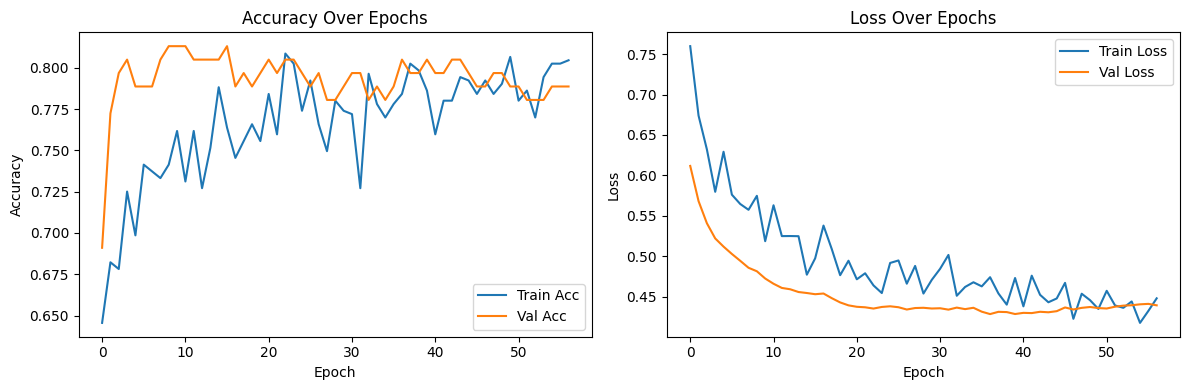


✅ Test Accuracy: 0.73, Test Loss: 0.5094
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


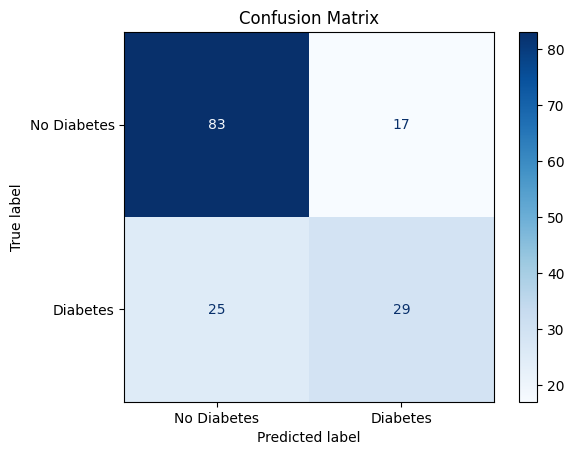


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       100
           1       0.63      0.54      0.58        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# 1. Load Dataset
data = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
    header=None
)
data.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# ---- VISUALIZATION 1: Correlation Heatmap ----
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

# ---- VISUALIZATION 2: Class Distribution ----
sns.countplot(x='Outcome', data=data)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

# 2. Preprocess
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Replace medically impossible zeros with NaN and impute with median
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Dense Neural Network Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 5. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Train with Early Stopping
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200, batch_size=32,
    callbacks=[es], verbose=1
)

# ---- VISUALIZATION 3: Training History ----
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 7. Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {acc:.2f}, Test Loss: {loss:.4f}")

# ---- VISUALIZATION 4: Confusion Matrix ----
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Optional: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
!pip install shap

In [ ]:
!apt-get install -y graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
737/737 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ExactExplainer explainer:   6%|▌         | 3/50 [00:00<?, ?it/s]

767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  10%|█         | 5/50 [00:19<02:00,  2.68s/it]

762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  12%|█▏        | 6/50 [00:20<01:33,  2.12s/it]

798/798 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  14%|█▍        | 7/50 [00:22<01:17,  1.81s/it]

756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  16%|█▌        | 8/50 [00:23<01:10,  1.69s/it]

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  18%|█▊        | 9/50 [00:25<01:06,  1.61s/it]

783/783 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  20%|██        | 10/50 [00:26<01:00,  1.51s/it]

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  22%|██▏       | 11/50 [00:27<00:59,  1.52s/it]

774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


ExactExplainer explainer:  24%|██▍       | 12/50 [00:29<00:58,  1.53s/it]

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  26%|██▌       | 13/50 [00:32<01:10,  1.91s/it]

789/789 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  28%|██▊       | 14/50 [00:33<01:02,  1.73s/it]

793/793 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  30%|███       | 15/50 [00:34<00:57,  1.65s/it]

755/755 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  32%|███▏      | 16/50 [00:36<00:54,  1.59s/it]

774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  34%|███▍      | 17/50 [00:37<00:49,  1.50s/it]

752/752 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  36%|███▌      | 18/50 [00:38<00:45,  1.43s/it]

774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  38%|███▊      | 19/50 [00:40<00:42,  1.38s/it]

767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  40%|████      | 20/50 [00:41<00:40,  1.35s/it]

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  42%|████▏     | 21/50 [00:44<00:52,  1.80s/it]

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  44%|████▍     | 22/50 [00:45<00:47,  1.70s/it]

791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  46%|████▌     | 23/50 [00:47<00:42,  1.59s/it]

773/773 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  48%|████▊     | 24/50 [00:48<00:40,  1.55s/it]

763/763 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  50%|█████     | 25/50 [00:49<00:36,  1.46s/it]

797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  52%|█████▏    | 26/50 [00:51<00:35,  1.48s/it]

769/769 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  54%|█████▍    | 27/50 [00:52<00:32,  1.42s/it]

748/748 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  56%|█████▌    | 28/50 [00:53<00:30,  1.37s/it]

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


ExactExplainer explainer:  58%|█████▊    | 29/50 [00:56<00:38,  1.81s/it]

765/765 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  60%|██████    | 30/50 [00:58<00:33,  1.68s/it]

794/794 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  62%|██████▏   | 31/50 [00:59<00:30,  1.59s/it]

762/762 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  64%|██████▍   | 32/50 [01:00<00:27,  1.55s/it]

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  66%|██████▌   | 33/50 [01:02<00:26,  1.55s/it]

796/796 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  68%|██████▊   | 34/50 [01:03<00:23,  1.49s/it]

737/737 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  70%|███████   | 35/50 [01:05<00:21,  1.43s/it]

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  72%|███████▏  | 36/50 [01:06<00:20,  1.44s/it]

792/792 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ExactExplainer explainer:  74%|███████▍  | 37/50 [01:09<00:24,  1.85s/it]

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  76%|███████▌  | 38/50 [01:10<00:20,  1.70s/it]

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  78%|███████▊  | 39/50 [01:12<00:17,  1.63s/it]

774/774 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  80%|████████  | 40/50 [01:13<00:15,  1.52s/it]

754/754 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  82%|████████▏ | 41/50 [01:14<00:13,  1.46s/it]

773/773 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  84%|████████▍ | 42/50 [01:16<00:11,  1.47s/it]

771/771 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  86%|████████▌ | 43/50 [01:17<00:09,  1.42s/it]

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  88%|████████▊ | 44/50 [01:19<00:08,  1.44s/it]

766/766 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


ExactExplainer explainer:  90%|█████████ | 45/50 [01:22<00:09,  1.87s/it]

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


ExactExplainer explainer:  92%|█████████▏| 46/50 [01:23<00:07,  1.81s/it]

773/773 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  94%|█████████▍| 47/50 [01:25<00:05,  1.70s/it]

799/799 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  96%|█████████▌| 48/50 [01:26<00:03,  1.64s/it]

747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:  98%|█████████▊| 49/50 [01:28<00:01,  1.58s/it]

770/770 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 100%|██████████| 50/50 [01:29<00:00,  1.57s/it]

800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 51it [01:31,  1.90s/it]


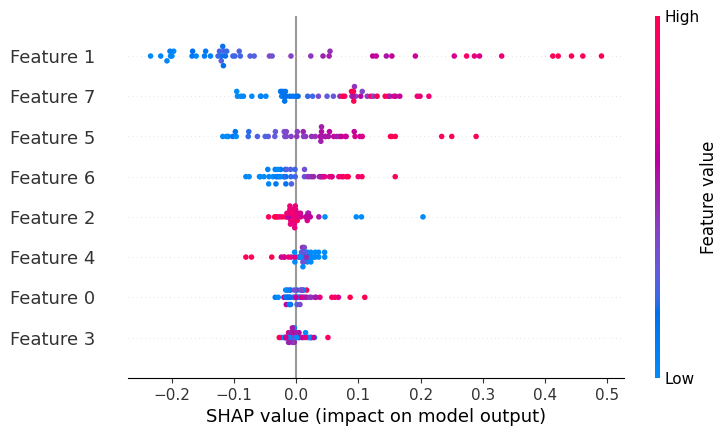

In [ ]:
# === XAI Section using SHAP on MLP ===
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reuse original 8 features without reshaping
X_raw = data.iloc[:, :-1].values
y_raw = data.iloc[:, -1].values

# Preprocessing
scaler_xai = StandardScaler()
X_scaled = scaler_xai.fit_transform(X_raw)

# Split data
X_train_xai, X_test_xai, y_train_xai, y_test_xai = train_test_split(X_scaled, y_raw, test_size=0.2, random_state=42)

# Train a simple MLP (Explainable)
mlp = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train_xai, y_train_xai, epochs=20, batch_size=16, verbose=0)

# ---- XAI: SHAP Explainer ----
explainer = shap.Explainer(mlp.predict, X_train_xai)
shap_values = explainer(X_test_xai[:50])  # Sample for faster rendering

# ---- XAI VISUALIZATION 1: Feature Importance (Global) ----
shap.plots.beeswarm(shap_values)

# ---- XAI VISUALIZATION 2: Force Plot (Single Prediction) ----
shap.initjs()
shap.plots.force(shap_values[0])

In [ ]:
###Diabetes Prediction using RNN + SHAP Explainability

# Diabetes Prediction using Ensemble + SHAP

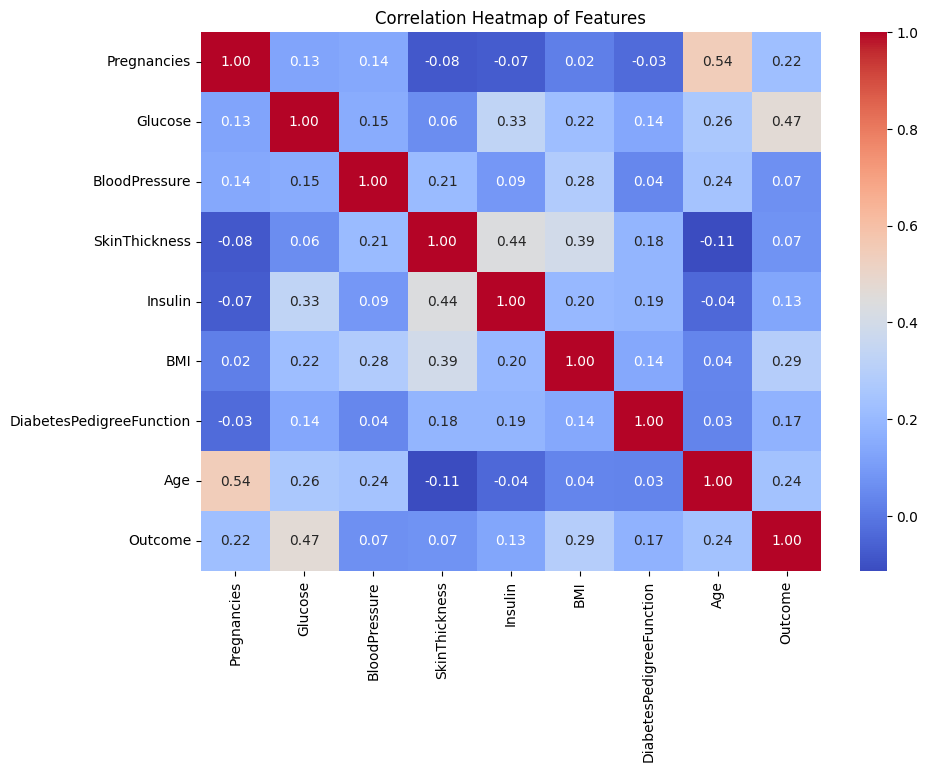

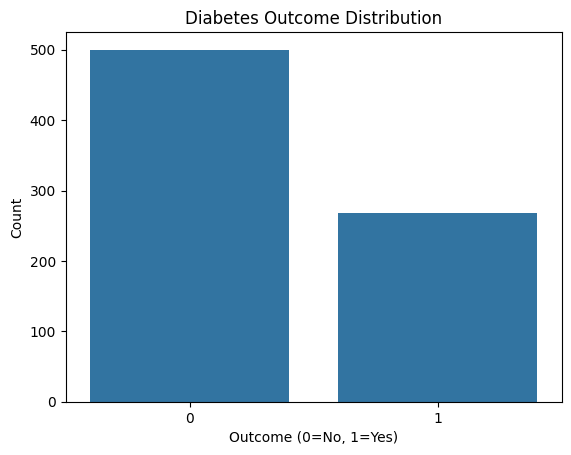


Individual Model Accuracies:

                 Model  Accuracy
0  Logistic Regression  0.701299
1                  SVM  0.733766
2        Random Forest  0.779221
3              XGBoost  0.759740

Top-2 Models for Ensemble:
Random Forest --> Accuracy: 0.7792
XGBoost --> Accuracy: 0.7597

✅ Voting Ensemble Accuracy: 0.753


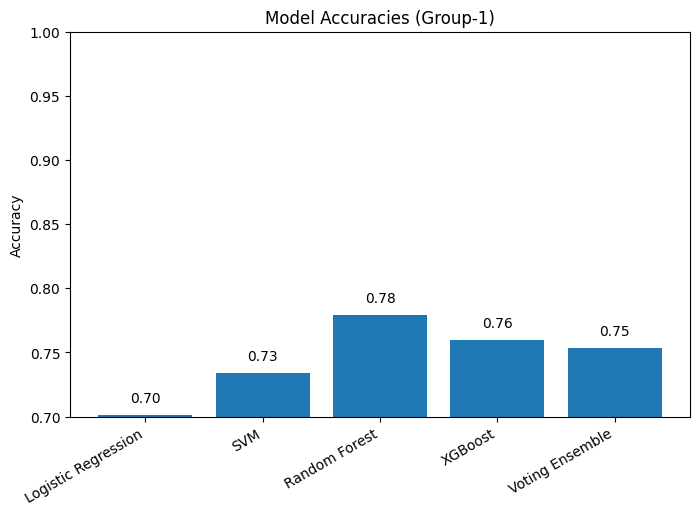

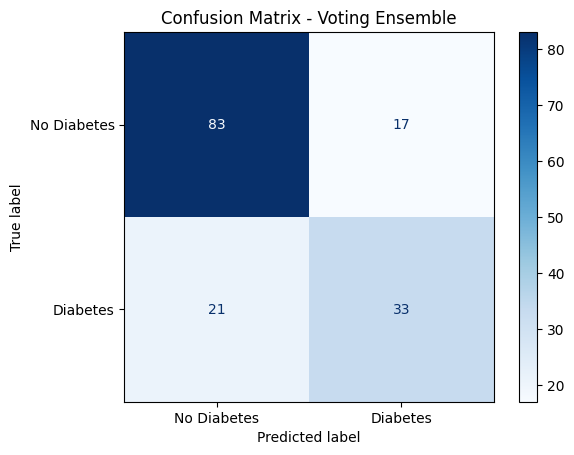


Classification Report (Voting Ensemble):

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
# ========================
# Classic ML Models (LR, SVM, RF, XGB) + Ensemble
# ========================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# 1. Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]

data = pd.read_csv(url, header=None, names=cols)

# ---- VISUALIZATION 1: Correlation Heatmap ----
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

# ---- VISUALIZATION 2: Class Distribution ----
sns.countplot(x="Outcome", data=data)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# 2. Preprocess
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Replace impossible zeros with median
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# 4. Train & Evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc, model))

# Accuracy table
results_df = pd.DataFrame([(r[0], r[1]) for r in results], columns=["Model","Accuracy"])
print("\nIndividual Model Accuracies:\n")
print(results_df)

# 5. Voting Ensemble (Top-2 models)
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
best_two = results_sorted[:2]
print("\nTop-2 Models for Ensemble:")
for m in best_two:
    print(f"{m[0]} --> Accuracy: {m[1]:.4f}")

ensemble = VotingClassifier(
    estimators=[(best_two[0][0], best_two[0][2]), (best_two[1][0], best_two[1][2])],
    voting="soft"
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)

ens_acc = accuracy_score(y_test, y_pred_ens)
print(f"\n✅ Voting Ensemble Accuracy: {ens_acc:.3f}")

# 6. ---- VISUALIZATION 3: Accuracy Bar Chart ----
results_dict = {r[0]:r[1] for r in results}
results_dict["Voting Ensemble"] = ens_acc

plt.figure(figsize=(8,5))
bars = plt.bar(results_dict.keys(), results_dict.values())
plt.title("Model Accuracies (Group-1)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.7,1.0)

for bar, acc in zip(bars, results_dict.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{acc:.2f}", ha="center")

plt.show()

# 7. ---- VISUALIZATION 4: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes","Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

# 8. Classification Report
print("\nClassification Report (Voting Ensemble):\n")
print(classification_report(y_test, y_pred_ens))


Logistic Regression -> Accuracy: 0.701, LogLoss: 0.514
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


SVM -> Accuracy: 0.734, LogLoss: 0.527
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154


RandomForest -> Accuracy: 0.779, LogLoss: 0.493
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                         

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:12:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost -> Accuracy: 0.760, LogLoss: 0.730
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:12:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Voting Ensemble -> Accuracy: 0.760, LogLoss: 0.500
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



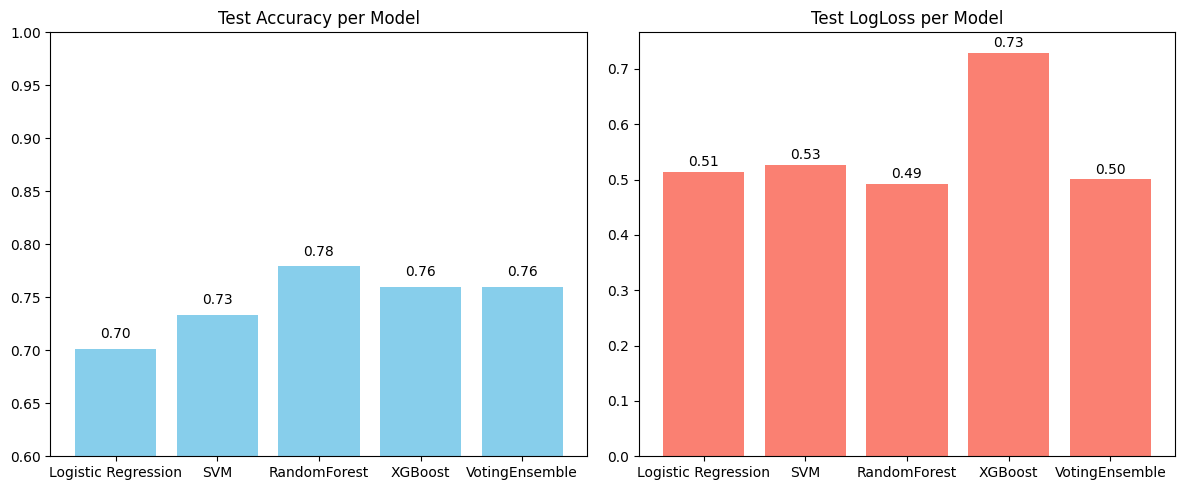

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# 1. Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]
data = pd.read_csv(url, header=None, names=cols)

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Replace 0 with NaN and fill
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = {}

# 3. Train + Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, model.predict_proba(X_test))
    results[name] = {"acc":acc, "loss":loss, "y_pred":y_pred}
    print(f"\n{name} -> Accuracy: {acc:.3f}, LogLoss: {loss:.3f}")
    print(classification_report(y_test, y_pred))

# 4. Voting Ensemble
ensemble = VotingClassifier(
    estimators=[(n,m) for n,m in models.items()],
    voting="soft"
)
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, ensemble.predict_proba(X_test))
results["VotingEnsemble"] = {"acc":acc,"loss":loss,"y_pred":y_pred}

print(f"\n✅ Voting Ensemble -> Accuracy: {acc:.3f}, LogLoss: {loss:.3f}")
print(classification_report(y_test, y_pred))

# 6. Visualization: Accuracy & Loss Comparison
names = list(results.keys())
accs = [results[n]["acc"] for n in names]
losses = [results[n]["loss"] for n in names]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(names, accs, color="skyblue")
plt.title("Test Accuracy per Model")
plt.ylim(0.6,1.0)
for i,v in enumerate(accs):
    plt.text(i, v+0.01, f"{v:.2f}", ha="center")

plt.subplot(1,2,2)
plt.bar(names, losses, color="salmon")
plt.title("Test LogLoss per Model")
for i,v in enumerate(losses):
    plt.text(i, v+0.01, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# --- Robust SHAP helper (paste & run in your notebook) ---
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

def _debug_print(msg, *args):
    try:
        # Use a consistent separator or join for args
        print(msg, *(str(a) for a in args))
    except Exception as e:
        print(f"Error in _debug_print: {e}")
        pass # Silently fail if printing causes an error

def extract_shap_matrix(shap_values, X, class_idx=1, verbose=False):
    """
    Convert various possible shap_values outputs into a 2D array of shape (n_samples, n_features)
    for the positive class (class_idx), which is what summary_plot expects in binary classification.

    shap_values  : can be
                   - a list of arrays (len = n_classes) where each item is (n_samples, n_features)
                   - a numpy array with shape (n_samples, n_features) or (n_outputs, n_samples, n_features) or (n_samples,n_outputs,n_features)
                   - a shap.Explanation object (has .values)
    X            : array-like or DataFrame used for determining n_samples and for plotting feature names
    class_idx    : which class to pick for binary problems (default 1)
    """
    X_arr = np.asarray(X)
    n_samples = X_arr.shape[0]
    n_features = X_arr.shape[1] # Get number of features from X

    sv = shap_values

    # If shap.Explanation wrapper passed (new API) - convert to underlying values
    if hasattr(sv, "values"):
        vals = np.asarray(sv.values)
        if verbose: _debug_print("shap.Explanation detected, values.shape =", vals.shape)
        # Explanation objects for multi-output have shape (n_samples, n_features, n_outputs)
        # We need (n_samples, n_features) for the selected class
        if vals.ndim == 3 and vals.shape[0] == n_samples and vals.shape[2] > 1:
             vals = vals[:, :, class_idx]
             if verbose: _debug_print("Extracted class_idx", class_idx, "from Explanation object. New shape =", vals.shape)
        elif vals.ndim == 3 and vals.shape[1] == n_samples and vals.shape[0] > 1:
             # Handle (n_outputs, n_samples, n_features) possibility for Explanation
             vals = vals[class_idx, :, :]
             if verbose: _debug_print("Extracted class_idx", class_idx, "from Explanation object (transposed case). New shape =", vals.shape)
        elif vals.ndim == 2 and vals.shape == (n_samples, n_features):
             # Already correct shape
             if verbose: _debug_print("Explanation values already correct 2D shape. Shape =", vals.shape)
        else:
             raise ValueError(f"Unhandled Explanation values shape {vals.shape}. Expected (n_samples, n_features, n_outputs) or (n_samples, n_features). X shape {X_arr.shape}.")

    # Handle list of arrays (common for KernelExplainer binary output)
    elif isinstance(sv, list) and len(sv) > 1 and np.asarray(sv[0]).ndim == 2:
         vals = np.asarray(sv[class_idx])
         if verbose: _debug_print("Extracted class_idx", class_idx, "from list of arrays. New shape =", vals.shape)

    # Handle direct numpy array
    elif isinstance(sv, np.ndarray):
        vals = sv
        if verbose: _debug_print("Direct numpy array detected. Shape =", vals.shape)
        # If it's 3D (e.g., from KernelExplainer for binary), try to select class
        if vals.ndim == 3 and vals.shape[0] == n_samples and vals.shape[2] > 1:
             vals = vals[:, :, class_idx]
             if verbose: _debug_print("Extracted class_idx", class_idx, "from 3D numpy array. New shape =", vals.shape)
        elif vals.ndim == 3 and vals.shape[1] == n_samples and vals.shape[0] > 1:
             # Handle (n_outputs, n_samples, n_features) possibility for numpy array
             vals = vals[class_idx, :, :]
             if verbose: _debug_print("Extracted class_idx", class_idx, "from 3D numpy array (transposed case). New shape =", vals.shape)
        elif vals.ndim == 1 and vals.shape[0] == n_samples * n_features:
             # Handle flattened array case - reshape it
             vals = vals.reshape(n_samples, n_features)
             if verbose: _debug_print("Reshaped 1D array to 2D ->", vals.shape)


    else:
         raise ValueError(f"Unhandled shap_values type {type(sv)} or shape. X shape {X_arr.shape}.")


    # Final shape check
    if vals.ndim == 2:
        # Should be (n_samples, n_features)
        if vals.shape[0] != n_samples or vals.shape[1] != n_features:
             if vals.shape[1] == n_samples and vals.shape[0] == n_features:
                vals = vals.T
                if verbose: _debug_print("Transposed vals to match n_samples, n_features ->", vals.shape)
             else:
                raise ValueError(f"Cannot match 2D shap array shape {vals.shape} with X shape {X_arr.shape} (n_samples, n_features: {n_samples}, {n_features})")
        return vals

    # If we reach here, something is still not right with the final shape
    raise ValueError(f"Final processed shap_values shape {vals.shape} is not 2D (n_samples, n_features). X shape {X_arr.shape}.")


def safe_shap_summary_plot(shap_values, X, feature_names=None, class_idx=1, max_display=20, verbose=False):
    """
    Safe wrapper: extracts 2D shap matrix and calls shap.summary_plot.
    X may be numpy array or DataFrame. feature_names optional (list).
    """
    # Ensure X is DataFrame for nice feature labels in plots
    if isinstance(X, np.ndarray):
        if feature_names is None:
            # create generic names
            feature_names = [f"f{i}" for i in range(X.shape[1])]
        X_df = pd.DataFrame(X, columns=feature_names)
    elif isinstance(X, pd.DataFrame):
        X_df = X.copy()
        if feature_names is None:
            feature_names = list(X_df.columns)
    else:
        X_df = pd.DataFrame(np.asarray(X), columns=feature_names) # Fallback if not array or DataFrame


    # Extract 2D SHAP array for the specified class
    try:
        shap_arr = extract_shap_matrix(shap_values, X_df, class_idx=class_idx, verbose=verbose)
    except ValueError as e:
        print(f"Error extracting SHAP matrix: {e}")
        if verbose: print("Original shap_values object:", shap_values)
        raise # Re-raise the exception after printing


    # Sanity print for debugging
    if verbose:
        _debug_print("Final shap_arr.shape:", shap_arr.shape, "X_df.shape:", X_df.shape)

    # Check if shapes match before plotting
    if shap_arr.shape[0] != X_df.shape[0] or shap_arr.shape[1] != X_df.shape[1]:
         raise AssertionError(f"Shape mismatch for plotting: shap_arr.shape {shap_arr.shape} vs X_df.shape {X_df.shape}")


    # call summary_plot (shap accepts numpy array + DataFrame)
    shap.summary_plot(shap_arr, X_df, max_display=max_display)


# -------------------------
# Example usage (run after you have models, X_train, X_test etc.)
# -------------------------
# Note: replace models["Random Forest"], X_test_df, X_train_df with your objects

# Example for a tree model (fast):
# explainer_rf = shap.TreeExplainer(models["Random Forest"])
# shap_exp_rf = explainer_rf(X_test_df)      # new API returns Explanation object
# safe_shap_summary_plot(shap_exp_rf, X_test_df, feature_names=X_test_df.columns, class_idx=1, verbose=True)

# Example for KernelExplainer (slow) for LR/SVM/Ensemble:
# background = shap.sample(X_train_df, 100, random_state=42)   # small background
# explainer_lr = shap.KernelExplainer(models["Logistic Regression"].predict_proba, background)
# shap_vals_lr = explainer_lr.shap_values(X_test_df.iloc[:50])
# safe_shap_summary_plot(shap_vals_lr, X_test_df.iloc[:50], feature_names=X_test_df.columns, class_idx=1, verbose=True)


================ RF (TreeExplainer) ================

shap.Explanation detected, values.shape = (154, 8, 2)
Extracted class_idx 1 from Explanation object. New shape = (154, 8)
Final shap_arr.shape: (154, 8) X_df.shape: (154, 8)


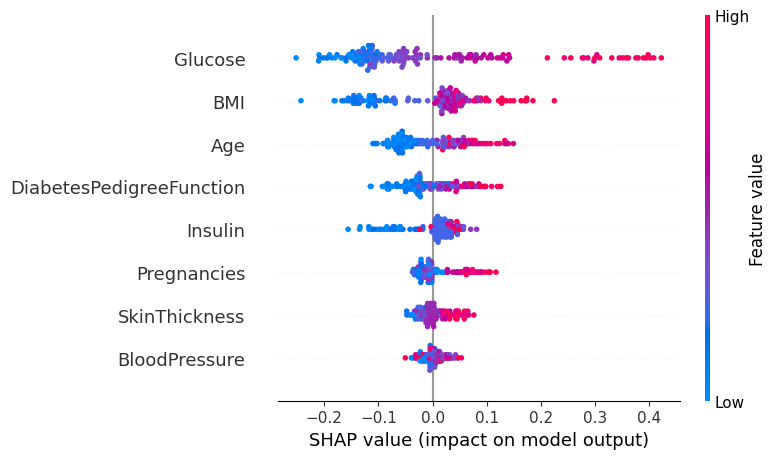


================ XGB (TreeExplainer) ================

shap.Explanation detected, values.shape = (154, 8)
Explanation values already correct 2D shape. Shape = (154, 8)
Final shap_arr.shape: (154, 8) X_df.shape: (154, 8)


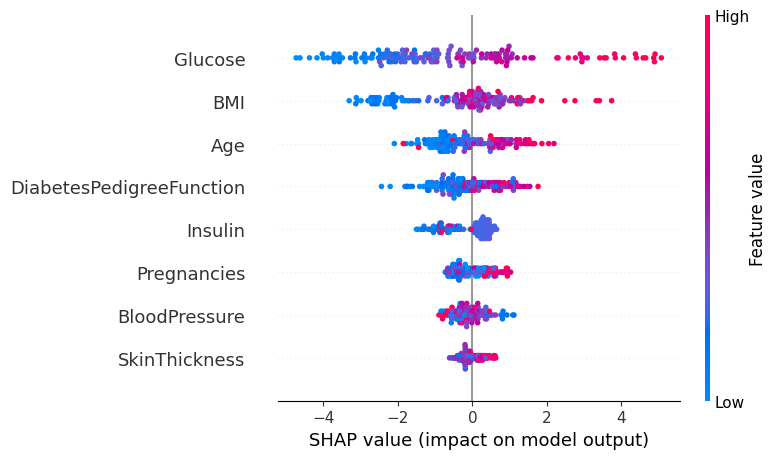


================ Logistic Regression (KernelExplainer) ================



  0%|          | 0/50 [00:00<?, ?it/s]

Direct numpy array detected. Shape = (50, 8, 2)
Extracted class_idx 1 from 3D numpy array. New shape = (50, 8)
Final shap_arr.shape: (50, 8) X_df.shape: (50, 8)


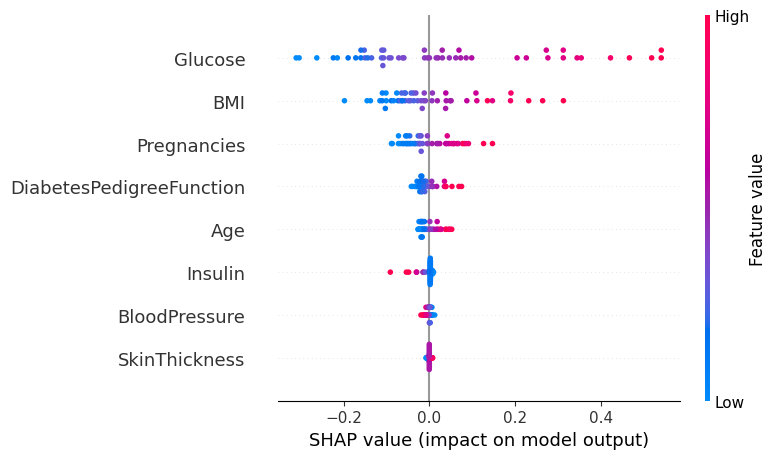


================ SVM (KernelExplainer) ================



  0%|          | 0/50 [00:00<?, ?it/s]

Direct numpy array detected. Shape = (50, 8, 2)
Extracted class_idx 1 from 3D numpy array. New shape = (50, 8)
Final shap_arr.shape: (50, 8) X_df.shape: (50, 8)


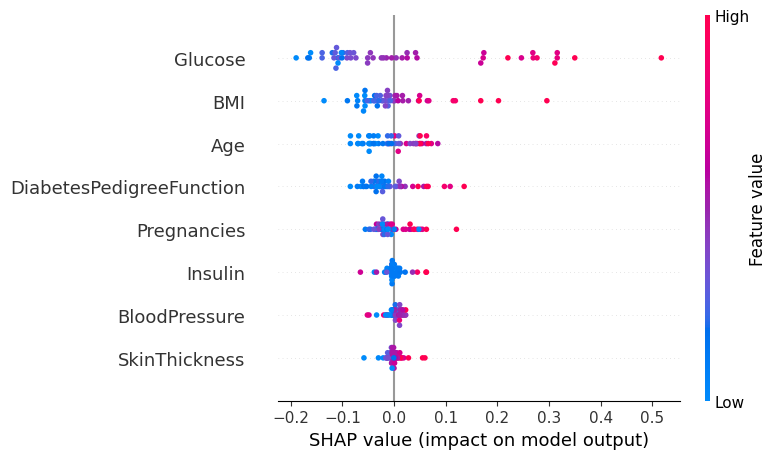


================ Voting Ensemble (KernelExplainer) ================



  0%|          | 0/50 [00:00<?, ?it/s]

Direct numpy array detected. Shape = (50, 8, 2)
Extracted class_idx 1 from 3D numpy array. New shape = (50, 8)
Final shap_arr.shape: (50, 8) X_df.shape: (50, 8)


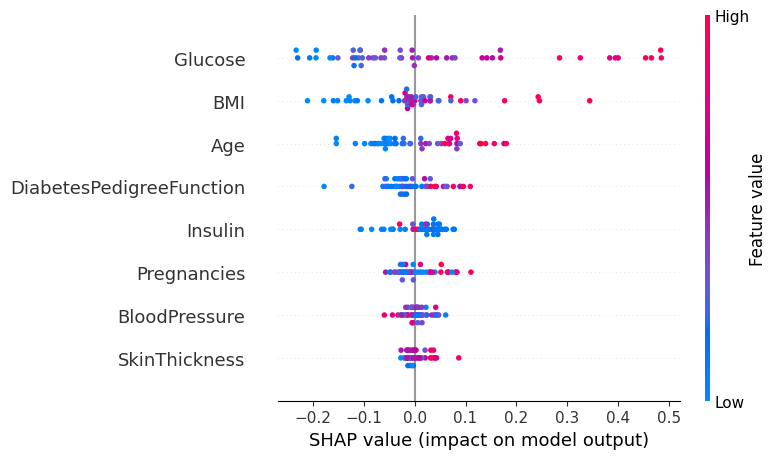

In [ ]:
# --- Ensure X_test as DataFrame for feature names ---
X_test_df = pd.DataFrame(X_test, columns=cols[:-1])
X_train_df = pd.DataFrame(X_train, columns=cols[:-1])

# --- Background sample for KernelExplainer (slow models) ---
# Using a small background sample (e.g., 100) for KernelExplainer speed
# Consider increasing for more accuracy if needed
background = shap.sample(X_train_df, 100, random_state=42)

print("\n================ RF (TreeExplainer) ================\n")
explainer_rf = shap.TreeExplainer(models["Random Forest"])
# TreeExplainer with new API returns Explanation object
shap_exp_rf = explainer_rf(X_test_df)
# safe_shap_summary_plot will handle selecting the correct dimension from Explanation object
safe_shap_summary_plot(shap_exp_rf, X_test_df, feature_names=cols[:-1], class_idx=1, verbose=True)


print("\n================ XGB (TreeExplainer) ================\n")
explainer_xgb = shap.TreeExplainer(models["XGBoost"])
# TreeExplainer with new API returns Explanation object
shap_exp_xgb = explainer_xgb(X_test_df)
# safe_shap_summary_plot will handle selecting the correct dimension from Explanation object
safe_shap_summary_plot(shap_exp_xgb, X_test_df, feature_names=cols[:-1], class_idx=1, verbose=True)

print("\n================ Logistic Regression (KernelExplainer) ================\n")
explainer_lr = shap.KernelExplainer(models["Logistic Regression"].predict_proba, background)
# KernelExplainer.shap_values returns a list of arrays for binary classification
shap_vals_lr = explainer_lr.shap_values(X_test_df.iloc[:50])   # 50 samples for speed
# safe_shap_summary_plot will handle selecting the correct dimension from the list
safe_shap_summary_plot(shap_vals_lr, X_test_df.iloc[:50], feature_names=cols[:-1], class_idx=1, verbose=True)

print("\n================ SVM (KernelExplainer) ================\n")
explainer_svm = shap.KernelExplainer(models["SVM"].predict_proba, background)
# KernelExplainer.shap_values returns a list of arrays for binary classification
shap_vals_svm = explainer_svm.shap_values(X_test_df.iloc[:50])
# safe_shap_summary_plot will handle selecting the correct dimension from the list
safe_shap_summary_plot(shap_vals_svm, X_test_df.iloc[:50], feature_names=cols[:-1], class_idx=1, verbose=True)


print("\n================ Voting Ensemble (KernelExplainer) ================\n")
explainer_ens = shap.KernelExplainer(ensemble.predict_proba, background)
# KernelExplainer.shap_values returns a list of arrays for binary classification
shap_vals_ens = explainer_ens.shap_values(X_test_df.iloc[:50])
# safe_shap_summary_plot will handle selecting the correct dimension from the list
safe_shap_summary_plot(shap_vals_ens, X_test_df.iloc[:50], feature_names=cols[:-1], class_idx=1, verbose=True)

In [ ]:
!pip install scikeras

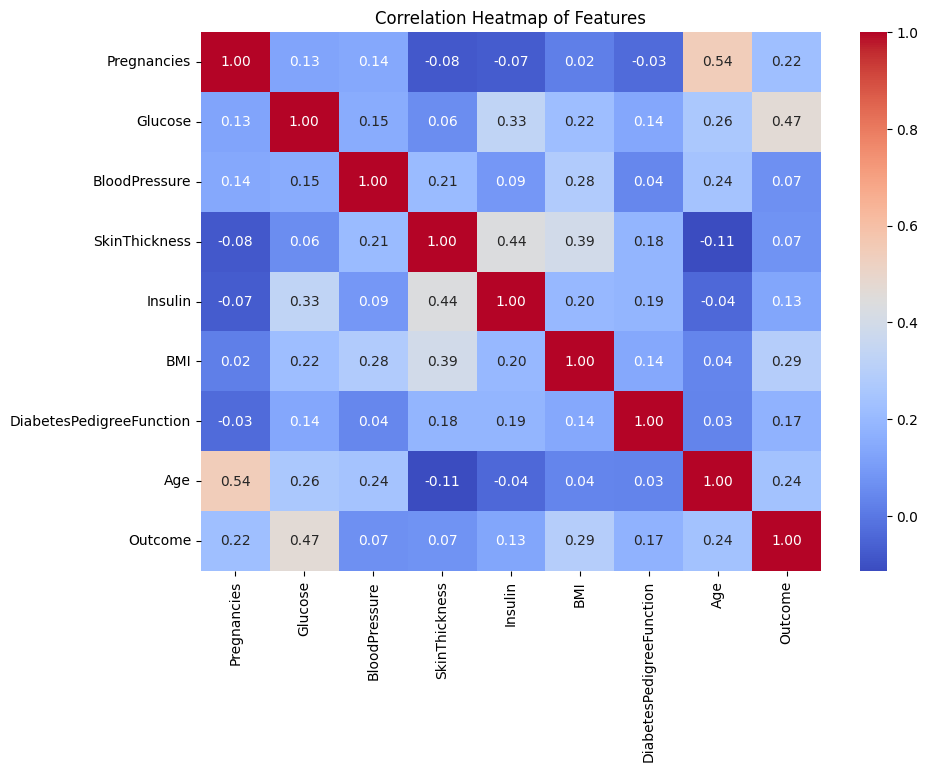

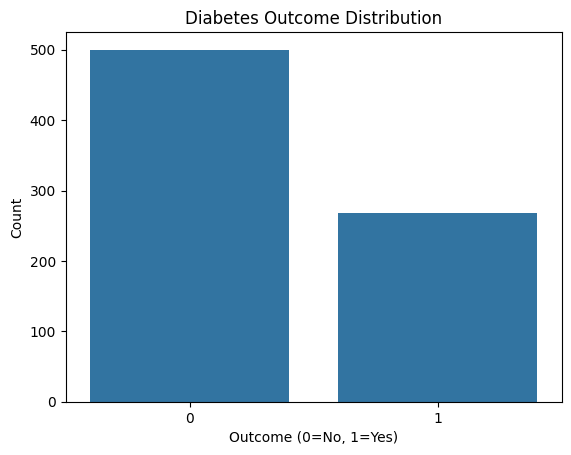


Individual Model Accuracies:

           Model  Accuracy
0            ANN  0.714286
1       AdaBoost  0.746753
2    Naive Bayes  0.701299
3            KNN  0.753247
4  Decision Tree  0.681818

✅ Voting Ensemble Accuracy: 0.760


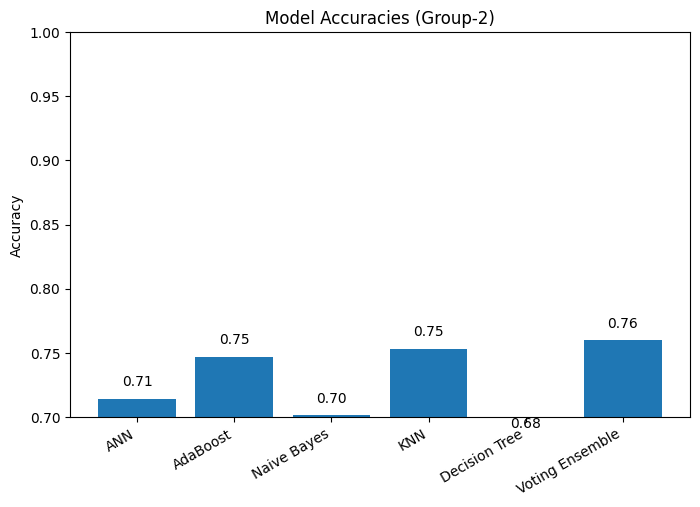

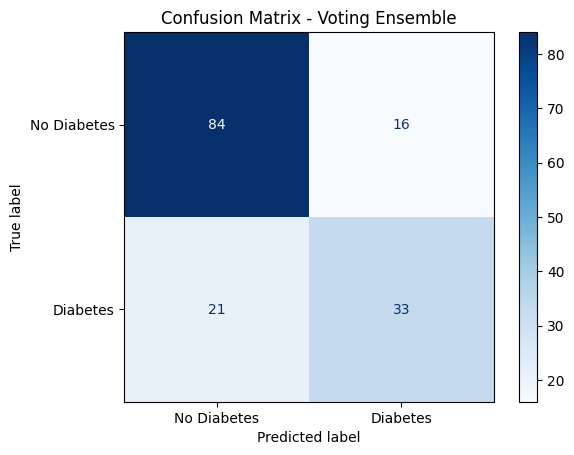


Classification Report (Voting Ensemble):

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------
# 1. Load dataset
# ---------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]

data = pd.read_csv(url, header=None, names=cols)

# ---- Visualization 1: Correlation Heatmap ----
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

# ---- Visualization 2: Class Distribution ----
sns.countplot(x="Outcome", data=data)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# ---------------------------
# 2. Preprocess
# ---------------------------
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Replace impossible zeros with median
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 3. Define Models
# ---------------------------
# ANN wrapper using scikeras
def create_ann():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann_model = KerasClassifier(model=create_ann, epochs=50, batch_size=32, verbose=0)

# Other ML models
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
nb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)

models = {
    "ANN": ann_model,
    "AdaBoost": ada,
    "Naive Bayes": nb,
    "KNN": knn,
    "Decision Tree": dt
}

# ---------------------------
# 4. Train & Evaluate Individually
# ---------------------------
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc, model))

results_df = pd.DataFrame([(r[0], r[1]) for r in results], columns=["Model","Accuracy"])
print("\nIndividual Model Accuracies:\n")
print(results_df)

# ---------------------------
# 5. Voting Ensemble (Top-2)
# ---------------------------
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
best_two = results_sorted[:2]  # choose top-2

ensemble = VotingClassifier(
    estimators=[(best_two[0][0], best_two[0][2]), (best_two[1][0], best_two[1][2])],
    voting="soft"
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
ens_acc = accuracy_score(y_test, y_pred_ens)

print(f"\n✅ Voting Ensemble Accuracy: {ens_acc:.3f}")

# ---------------------------
# 6. Accuracy Bar Chart
# ---------------------------
results_dict = {r[0]:r[1] for r in results}
results_dict["Voting Ensemble"] = ens_acc

plt.figure(figsize=(8,5))
bars = plt.bar(results_dict.keys(), results_dict.values())
plt.title("Model Accuracies (Group-2)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.7,1.0)
for bar, acc in zip(bars, results_dict.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{acc:.2f}", ha="center")
plt.show()

# ---------------------------
# 7. Confusion Matrix & Classification Report
# ---------------------------
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes","Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

print("\nClassification Report (Voting Ensemble):\n")
print(classification_report(y_test, y_pred_ens))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3979 - loss: 0.7883 - val_accuracy: 0.6169 - val_loss: 0.6434
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6514 - loss: 0.5933 - val_accuracy: 0.6948 - val_loss: 0.5689
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7079 - loss: 0.5432 - val_accuracy: 0.7338 - val_loss: 0.5392
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6953 - loss: 0.5322 - val_accuracy: 0.7338 - val_loss: 0.5243
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7562 - loss: 0.4980 - val_accuracy: 0.7208 - val_loss: 0.5140
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7650 - loss: 0.4937 - val_accuracy: 0.7273 - val_loss: 0.5087
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7685 - loss: 0.4728 - val_accuracy: 0.7338 - val_loss: 0.5052
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7880 - loss: 0.4689 - val_accuracy: 0.7403 - val_loss: 0.5051
Ep

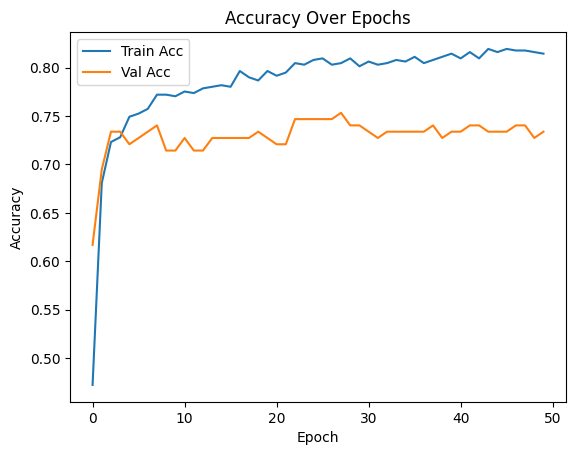

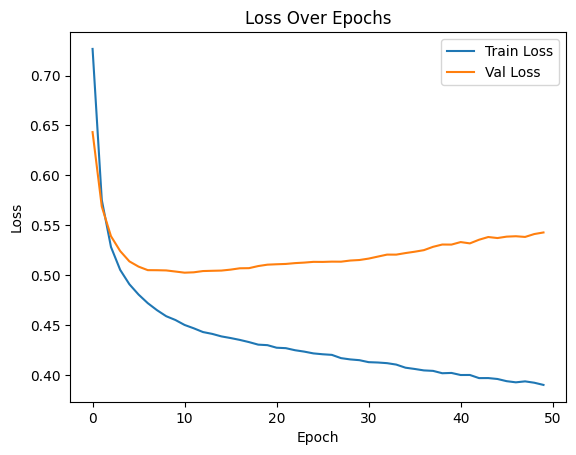

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Confusion Matrix:
 [[76 23]
 [18 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79        99
           1       0.62      0.67      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Suppose X, y already loaded (your diabetes dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN model
model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}, Test Loss: {test_loss:.3f}")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix + Report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
!pip install scikeras shap


Individual Model Accuracies:
            Model  Accuracy
0            ANN  0.727273
1       AdaBoost  0.746753
2    Naive Bayes  0.701299
3            KNN  0.753247
4  Decision Tree  0.681818

✅ Voting Ensemble Accuracy: 0.760

================ ANN SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

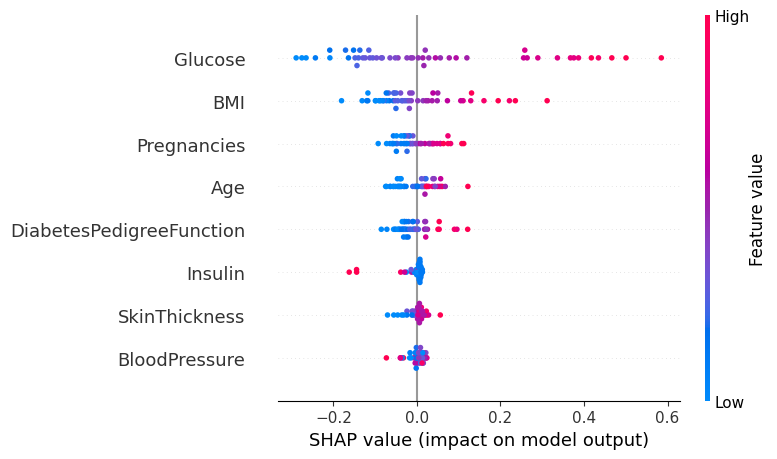


================ AdaBoost SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

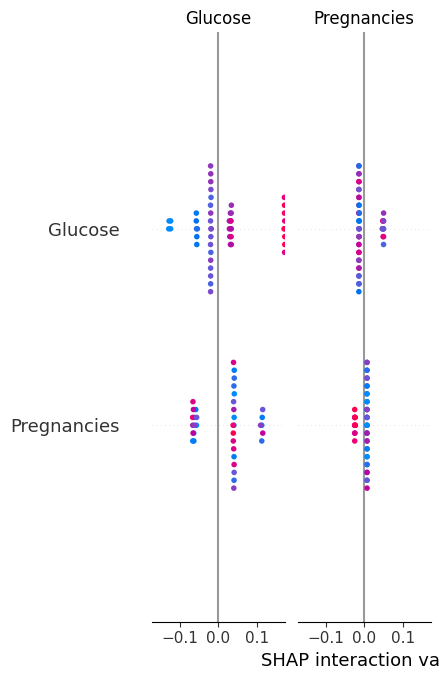


================ Naive Bayes SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

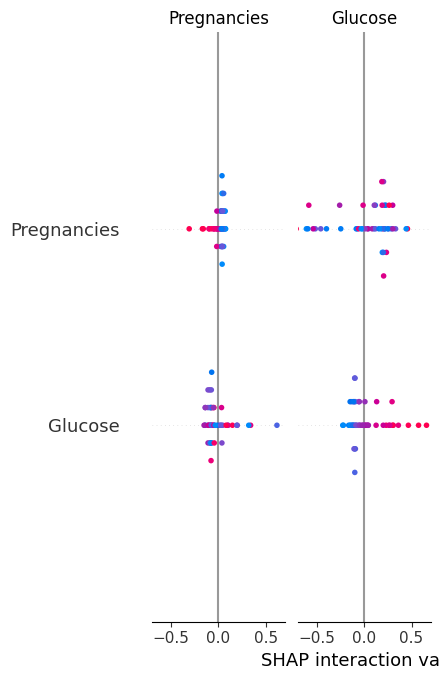


================ KNN SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

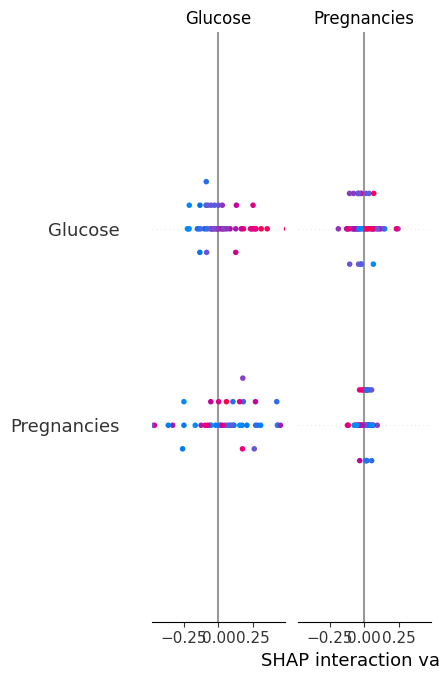


================ Decision Tree SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

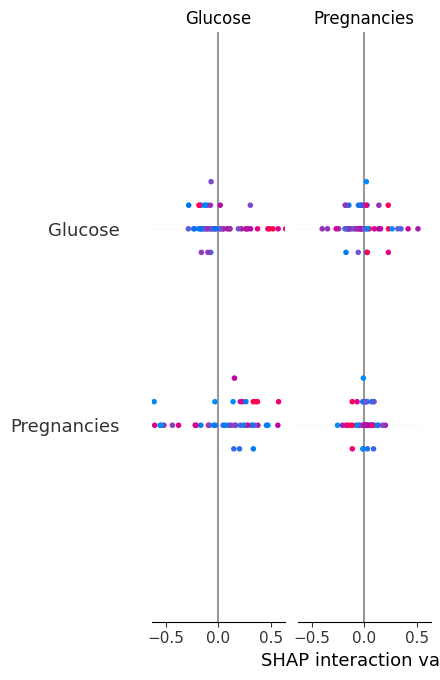


================ Voting Ensemble SHAP ================



  0%|          | 0/50 [00:00<?, ?it/s]

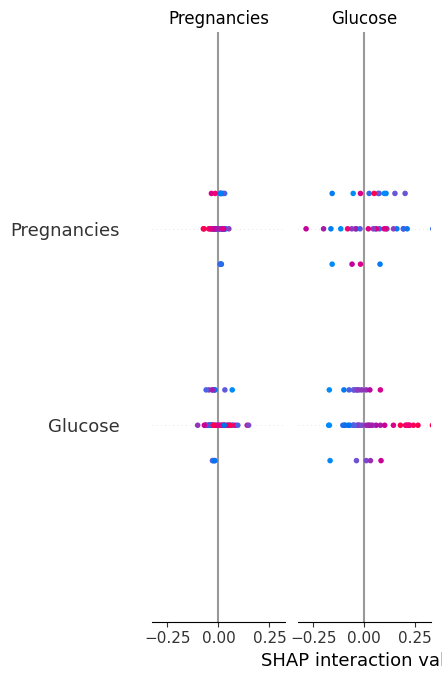

ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
# ========================
# 5 Models + Voting Ensemble + SHAP (Final, Stable)
# ========================

# !pip install scikeras shap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import shap

# ---------------------------
# 1. Load Dataset
# ---------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]

data = pd.read_csv(url, header=None, names=cols)

X = data.drop("Outcome", axis=1)
y = data["Outcome"].values  # NumPy array

cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# ---------------------------
# 2. Scale Features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # NumPy array
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 3. Define Models
# ---------------------------
def create_ann():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann_model = KerasClassifier(model=create_ann, epochs=50, batch_size=32, verbose=0)
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
nb = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)

models = {
    "ANN": ann_model,
    "AdaBoost": ada,
    "Naive Bayes": nb,
    "KNN": knn,
    "Decision Tree": dt
}

# ---------------------------
# 4. Train Models
# ---------------------------
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc, model))

results_df = pd.DataFrame([(r[0], r[1]) for r in results], columns=["Model","Accuracy"])
print("\nIndividual Model Accuracies:\n", results_df)

# ---------------------------
# 5. Voting Ensemble (Top-2 Models)
# ---------------------------
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
best_two = results_sorted[:2]

ensemble = VotingClassifier(
    estimators=[(best_two[0][0], best_two[0][2]), (best_two[1][0], best_two[1][2])],
    voting="soft"
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
ens_acc = accuracy_score(y_test, y_pred_ens)
print(f"\n✅ Voting Ensemble Accuracy: {ens_acc:.3f}")

# ---------------------------
# 6. SHAP Analysis
# ---------------------------
background = shap.sample(X_train, 100, random_state=42)
X_subset = X_test[:50]

# ANN predict wrapper: flatten output
def ann_predict(X_input):
    return ann_model.model_.predict(X_input, verbose=0).flatten()

def safe_shap_summary_plot(shap_values, X_array, feature_names):
    try:
        shap.summary_plot(shap_values, X_array, feature_names=feature_names, show=True)
    except Exception as e:
        print("Error in SHAP summary plot:", e)

# --- Individual Models SHAP ---
for name, _, model in results:
    print(f"\n================ {name} SHAP ================\n")
    if name == "ANN":
        explainer = shap.KernelExplainer(ann_predict, background)
        shap_vals = explainer.shap_values(X_subset)
    else:
        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_vals = explainer.shap_values(X_subset)
    # take positive class
    if isinstance(shap_vals, list):
        shap_vals_class1 = shap_vals[1]
    else:
        shap_vals_class1 = shap_vals
    safe_shap_summary_plot(shap_vals_class1, X_subset, feature_names=X.columns)

# --- Ensemble SHAP ---
print(f"\n================ Voting Ensemble SHAP ================\n")
explainer_ens = shap.KernelExplainer(ensemble.predict_proba, background)
shap_vals_ens = explainer_ens.shap_values(X_subset)
if isinstance(shap_vals_ens, list):
    shap_vals_ens_class1 = shap_vals_ens[1]
else:
    shap_vals_ens_class1 = shap_vals_ens
safe_shap_summary_plot(shap_vals_ens_class1, X_subset, feature_names=X.columns)

# ---------------------------
# 7. Average SHAP Bar Chart
# ---------------------------
mean_abs_shap = np.mean(np.abs(shap_vals_ens_class1), axis=0)
shap_df = pd.DataFrame({'Feature': X.columns, 'Mean |SHAP|': mean_abs_shap})
shap_df = shap_df.sort_values('Mean |SHAP|', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Mean |SHAP|', y='Feature', data=shap_df, palette='viridis')
plt.title("Average SHAP Feature Importance (Voting Ensemble)")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# ---------------------------
# 8. Ensemble Evaluation
# ---------------------------
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes","Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

print("\nClassification Report (Voting Ensemble):\n")
print(classification_report(y_test, y_pred_ens))

In [ ]:
!pip install scikeras

Training Logistic Regression...
Training SVM...
Training Random Forest...
Training XGBoost...
Training ANN...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:27:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training AdaBoost...
Training Naive Bayes...
Training KNN...
Training Decision Tree...

Individual Model Accuracies:

                 Model  Accuracy
2        Random Forest  0.779221
3              XGBoost  0.759740
7                  KNN  0.753247
5             AdaBoost  0.746753
4                  ANN  0.733766
1                  SVM  0.733766
0  Logistic Regression  0.701299
6          Naive Bayes  0.701299
8        Decision Tree  0.681818

Top-2 Models: Random Forest and XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:27:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Voting Ensemble Accuracy: 0.753


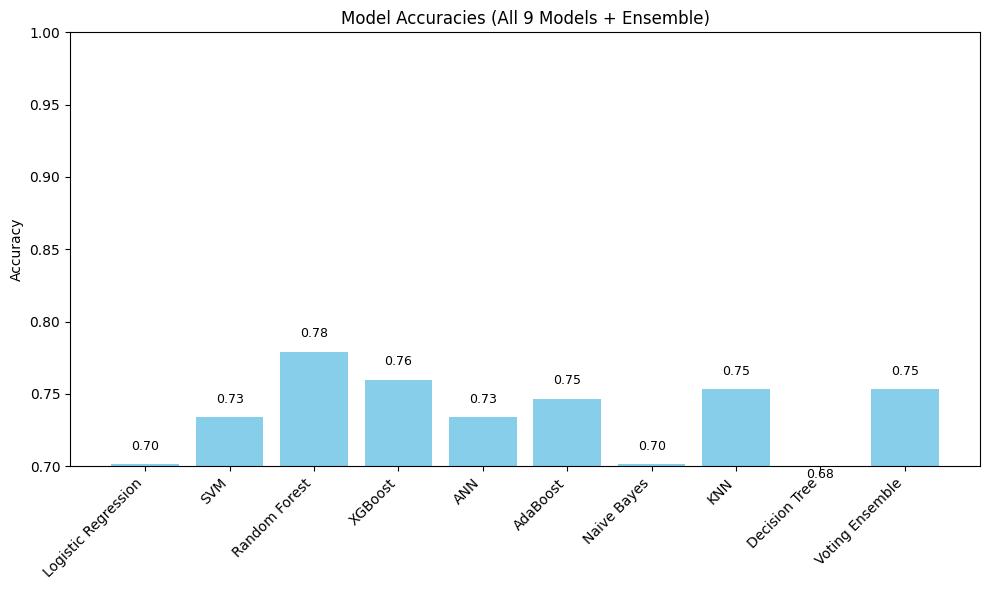

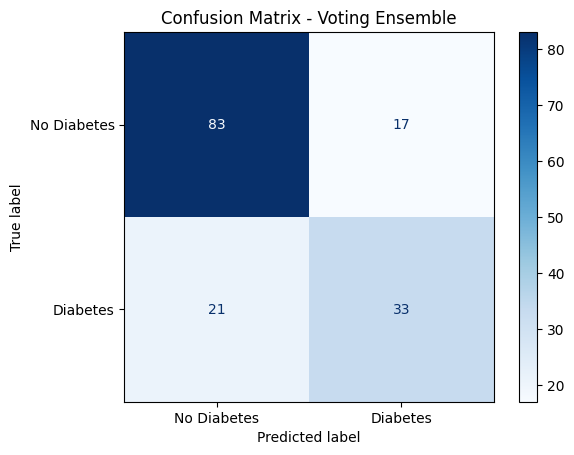


Classification Report (Voting Ensemble):

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
# =========================================
# 9-Model Ensemble: Pima Indians Diabetes
# =========================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------
# 1. Load dataset
# ---------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]

data = pd.read_csv(url, header=None, names=cols)

# ---------------------------
# 2. Preprocess
# ---------------------------
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Replace impossible zeros with median
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------------------
# 3. Define Models
# ---------------------------

# ANN using scikeras
def create_ann():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

ann_model = KerasClassifier(model=create_ann, epochs=50, batch_size=32, verbose=0)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "ANN": ann_model,
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# ---------------------------
# 4. Train & Evaluate Individually
# ---------------------------
results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc, model))

results_df = pd.DataFrame([(r[0], r[1]) for r in results], columns=["Model","Accuracy"])
print("\nIndividual Model Accuracies:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))

# ---------------------------
# 5. Voting Ensemble (Top-2)
# ---------------------------
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
best_two = results_sorted[:2]  # choose top-2

print(f"\nTop-2 Models: {best_two[0][0]} and {best_two[1][0]}")

ensemble = VotingClassifier(
    estimators=[(best_two[0][0], best_two[0][2]), (best_two[1][0], best_two[1][2])],
    voting="soft"
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
ens_acc = accuracy_score(y_test, y_pred_ens)

print(f"\n✅ Voting Ensemble Accuracy: {ens_acc:.3f}")

# ---------------------------
# 6. Accuracy Bar Chart
# ---------------------------
results_dict = {r[0]:r[1] for r in results}
results_dict["Voting Ensemble"] = ens_acc

plt.figure(figsize=(10,6))
bars = plt.bar(results_dict.keys(), results_dict.values(), color='skyblue')
plt.title("Model Accuracies (All 9 Models + Ensemble)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.7,1.0)
for bar, acc in zip(bars, results_dict.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{acc:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------
# 7. Confusion Matrix & Classification Report
# ---------------------------
cm = confusion_matrix(y_test, y_pred_ens)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes","Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Voting Ensemble")
plt.show()

print("\nClassification Report (Voting Ensemble):\n")
print(classification_report(y_test, y_pred_ens))
